<a href="https://colab.research.google.com/github/Nitinda97/EDA-on-NYC-Taxi/blob/main/EDA_Assg_NYC_Taxi_Nitin_Khare.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description
You can find the data description here: [Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [2]:
# Import warnings

import warnings
warnings.filterwarnings("ignore")

In [3]:
# Import the libraries you will be using for analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

In [6]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 2.0.2
pandas version: 2.2.2
matplotlib version: 3.10.0
seaborn version: 0.13.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [77]:
# Try loading one file

df = pd.read_parquet('/content/sample_data/2023-1.parquet')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3041714 entries, 0 to 3066765
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            floa

How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [ ]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload

In [78]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [79]:
# Take a small percentage of entries from each hour of every date.
# Iterating through the monthly data:
#   read a month file -> day -> hour: append sampled data -> move to next hour -> move to next day after 24 hours -> move to next month file
# Create a single dataframe for the year combining all the monthly data

# Select the folder having data files
import os

# Select the folder having data files
os.chdir('/content/drive/MyDrive/Assignments/EDA/data_NYC_Taxi/trip_records')

# Create a list of all the twelve files to read
file_list = os.listdir()

# initialise an empty dataframe
df = pd.DataFrame()


# iterate through the list of files and sample one by one:
for file_name in file_list:
    try:
        # file path for the current file
        file_path = os.path.join(os.getcwd(), file_name)

        # Reading the current file

        month_data = pd.read_parquet(file_path)
        dt_col = 'tpep_pickup_datetime'
        # Ensure the column is explicitly in datetime format
        month_data[dt_col] = pd.to_datetime(month_data[dt_col])

        # Create temporary columns for 'date' and 'hour' to facilitate grouping
        month_data['pickup_date'] = month_data[dt_col].dt.date
        month_data['pickup_hour'] = month_data[dt_col].dt.hour

        # Loop through dates and then loop through every hour of each date:
        # Instead of manual loops, we use vectorized grouping to sample 5% (frac=0.05) of the hourly data randomly.
        # This executes the hour/date logic exponentially faster.
        sampled_data = month_data.groupby(['pickup_date', 'pickup_hour']).sample(frac=0.05, random_state=42)

        # Drop the temporary date and hour columns to maintain the original dataframe schema
        sampled_data = sampled_data.drop(columns=['pickup_date', 'pickup_hour'])

        # Concatenate the sampled data of all the dates to the single master dataframe
        df = pd.concat([df, sampled_data], ignore_index=True)
        print(f"Successfully sampled and appended {file_name}. Current total rows: {len(df)}")

    except Exception as e:
        print(f"Error reading file {file_name}: {e}")
print(f"Total sampled records: {len(df)}")

Successfully sampled and appended 2023-1.parquet. Current total rows: 152087
Successfully sampled and appended 2023-2.parquet. Current total rows: 320783
Successfully sampled and appended 2023-3.parquet. Current total rows: 484569
Successfully sampled and appended 2023-4.parquet. Current total rows: 624210
Successfully sampled and appended 2023-5.parquet. Current total rows: 768668
Successfully sampled and appended 2023-6.parquet. Current total rows: 931578
Successfully sampled and appended 2023-7.parquet. Current total rows: 1105646
Successfully sampled and appended 2023-8.parquet. Current total rows: 1249428
Successfully sampled and appended 2023-9.parquet. Current total rows: 1390303
Successfully sampled and appended 2023-10.parquet. Current total rows: 1564558
Successfully sampled and appended 2023-11.parquet. Current total rows: 1729691
Successfully sampled and appended 2023-12.parquet. Current total rows: 1896400
Error reading file sampledtaxi2023.csv: [Errno 2] No such file or d

After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [80]:
# Store the df in csv/parquet
df.to_csv("/content/drive/MyDrive/Assignments/EDA/data_NYC_Taxi/trip_records/sampledtaxi2023.csv")

## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [81]:
# Load the new data file
df=pd.read_csv("/content/drive/MyDrive/Assignments/EDA/data_NYC_Taxi/trip_records/sampledtaxi2023.csv")


In [82]:
df.head()

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,...,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,Airport_fee
0,0,2,2022-12-31 23:36:04,2022-12-31 23:43:31,1.0,1.69,1.0,N,43,141,...,10.0,1.0,0.5,3.00,0.0,1.0,18.00,2.5,0.0,NaN
1,1,1,2023-01-01 00:59:47,2023-01-01 01:23:42,NaN,0.00,NaN,NaN,68,45,...,35.3,0.0,0.5,0.00,0.0,1.0,39.30,NaN,NaN,NaN
2,2,2,2023-01-01 00:18:34,2023-01-01 00:23:55,1.0,0.99,1.0,N,144,211,...,7.2,1.0,0.5,0.00,0.0,1.0,12.20,2.5,0.0,NaN
3,3,2,2023-01-01 00:32:27,2023-01-01 00:37:01,2.0,0.92,1.0,N,79,107,...,7.2,1.0,0.5,3.05,0.0,1.0,15.25,2.5,0.0,NaN
4,4,1,2023-01-01 00:26:11,2023-01-01 00:40:21,2.0,2.30,1.0,Y,48,238,...,13.5,3.5,0.5,4.60,0.0,1.0,23.10,2.5,0.0,NaN


In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1896400 entries, 0 to 1896399
Data columns (total 21 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Unnamed: 0             int64  
 1   VendorID               int64  
 2   tpep_pickup_datetime   object 
 3   tpep_dropoff_datetime  object 
 4   passenger_count        float64
 5   trip_distance          float64
 6   RatecodeID             float64
 7   store_and_fwd_flag     object 
 8   PULocationID           int64  
 9   DOLocationID           int64  
 10  payment_type           int64  
 11  fare_amount            float64
 12  extra                  float64
 13  mta_tax                float64
 14  tip_amount             float64
 15  tolls_amount           float64
 16  improvement_surcharge  float64
 17  total_amount           float64
 18  congestion_surcharge   float64
 19  airport_fee            float64
 20  Airport_fee            float64
dtypes: float64(13), int64(5), object(3)
memory usage: 303.

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [84]:
# Fix the index and drop any columns that are not needed

df.reset_index(drop=True, inplace=True)
df = df.drop(['Unnamed: 0'], axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1896400 entries, 0 to 1896399
Data columns (total 20 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   VendorID               int64  
 1   tpep_pickup_datetime   object 
 2   tpep_dropoff_datetime  object 
 3   passenger_count        float64
 4   trip_distance          float64
 5   RatecodeID             float64
 6   store_and_fwd_flag     object 
 7   PULocationID           int64  
 8   DOLocationID           int64  
 9   payment_type           int64  
 10  fare_amount            float64
 11  extra                  float64
 12  mta_tax                float64
 13  tip_amount             float64
 14  tolls_amount           float64
 15  improvement_surcharge  float64
 16  total_amount           float64
 17  congestion_surcharge   float64
 18  airport_fee            float64
 19  Airport_fee            float64
dtypes: float64(13), int64(4), object(3)
memory usage: 289.4+ MB


**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [85]:
# Combine the two airport fee columns

df['airport_fee_combined'] = df[['airport_fee', 'Airport_fee']].max(axis=1)
df = df.drop(['airport_fee', 'Airport_fee'], axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1896400 entries, 0 to 1896399
Data columns (total 19 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   VendorID               int64  
 1   tpep_pickup_datetime   object 
 2   tpep_dropoff_datetime  object 
 3   passenger_count        float64
 4   trip_distance          float64
 5   RatecodeID             float64
 6   store_and_fwd_flag     object 
 7   PULocationID           int64  
 8   DOLocationID           int64  
 9   payment_type           int64  
 10  fare_amount            float64
 11  extra                  float64
 12  mta_tax                float64
 13  tip_amount             float64
 14  tolls_amount           float64
 15  improvement_surcharge  float64
 16  total_amount           float64
 17  congestion_surcharge   float64
 18  airport_fee_combined   float64
dtypes: float64(12), int64(4), object(3)
memory usage: 274.9+ MB


**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [86]:
# check where values of fare amount are negative

df[df['fare_amount'] < 0]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee_combined


Did you notice something different in the `RatecodeID` column for above records?

In [87]:
# Analyse RatecodeID for the negative fare amounts

df[df['fare_amount'] < 0]['RatecodeID'].value_counts()

,count
RatecodeID,


In [88]:
# Find which columns have negative values
# Select only numeric columns from the DataFrame
numeric_cols = df.select_dtypes(include=['number'])

# Count the number of negative values in each numeric column
negative_counts = (numeric_cols < 0).sum()

# Filter to show only columns that have at least one negative value
cols_with_negatives = negative_counts[negative_counts > 0]

# Display the results
print("Columns with negative values and their counts:")
print(cols_with_negatives)


Columns with negative values and their counts:
extra                     2
mta_tax                  80
improvement_surcharge    88
total_amount             88
congestion_surcharge     56
airport_fee_combined     26
dtype: int64


In [89]:
# fix these negative values
columns_to_fix = cols_with_negatives.index
df[columns_to_fix] = df[columns_to_fix].abs()
# Verified that no negative values remain
print("Count of negative values after fix:")
print((df[columns_to_fix] < 0).sum())

Count of negative values after fix:
extra                    0
mta_tax                  0
improvement_surcharge    0
total_amount             0
congestion_surcharge     0
airport_fee_combined     0
dtype: int64


### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [90]:
# Find the proportion of missing values in each column

# Calculate the proportion of missing values in each column
missing_proportion = df.isnull().mean()

# Convert to percentage and sort in descending order
missing_percentage = (missing_proportion * 100).sort_values(ascending=False)

print("Percentage of missing values per column:")
print(missing_percentage)


Percentage of missing values per column:
store_and_fwd_flag       3.42549
RatecodeID               3.42549
passenger_count          3.42549
airport_fee_combined     3.42549
congestion_surcharge     3.42549
VendorID                 0.00000
tpep_pickup_datetime     0.00000
tpep_dropoff_datetime    0.00000
DOLocationID             0.00000
PULocationID             0.00000
trip_distance            0.00000
fare_amount              0.00000
payment_type             0.00000
extra                    0.00000
mta_tax                  0.00000
tolls_amount             0.00000
tip_amount               0.00000
total_amount             0.00000
improvement_surcharge    0.00000
dtype: float64


**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [91]:
# Display the rows with null values
df[df.isnull().any(axis=1)]

# 2. Impute NaN values in 'passenger_count'
df.fillna({'passenger_count': df['passenger_count'].mode()[0]}, inplace=True)

# Verify the missing values have been resolved
remaining_nulls = df['passenger_count'].isnull().sum()
print(f"Remaining nulls in passenger_count: {remaining_nulls}")

Remaining nulls in passenger_count: 0


Did you find zeroes in passenger_count? Handle these.

**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [92]:
# Fix missing values in 'RatecodeID'
df['RatecodeID'] = df['RatecodeID'].fillna(df['RatecodeID'].mode()[0])
# Verify the missing values have been resolved
remaining_nulls = df['RatecodeID'].isnull().sum()
print(f"Remaining nulls in RatecodeID: {remaining_nulls}")

Remaining nulls in RatecodeID: 0


**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [93]:
# handle null values in congestion_surcharge
congestion_mode = df['congestion_surcharge'].mode()[0]
df['congestion_surcharge'].fillna(congestion_mode, inplace=True)
# Verify the missing values have been resolved
remaining_nulls = df['congestion_surcharge'].isnull().sum()
print(f"Remaining nulls in congestion_surcharge: {remaining_nulls}")

Remaining nulls in congestion_surcharge: 0


Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [94]:
# Handle any remaining missing values
# For store_and_fwd_flag (categorical)
df['store_and_fwd_flag'].fillna(df['store_and_fwd_flag'].mode()[0], inplace=True)
# For airport_fee_combined (numeric)
df['airport_fee_combined'].fillna(0, inplace=True)
# Verify the missing values have been resolved
remaining_nulls = df['store_and_fwd_flag'].isnull().sum()
print(f"Remaining nulls in store_and_fwd_flag: {remaining_nulls}")
remaining_nulls = df['airport_fee_combined'].isnull().sum()
print(f"Remaining nulls in airport_fee_combined: {remaining_nulls}")

Remaining nulls in store_and_fwd_flag: 0
Remaining nulls in airport_fee_combined: 0


### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

In [95]:
# Describe the data and check if there are any potential outliers present
# Check for potential out of place values in various columns
print(df.describe())
num_cols = ['trip_distance', 'fare_amount', 'total_amount', 'tip_amount', 'passenger_count','tolls_amount']



           VendorID  passenger_count  trip_distance    RatecodeID  \
count  1.896400e+06     1.896400e+06   1.896400e+06  1.896400e+06   
mean   1.735933e+00     1.357067e+00   3.966358e+00  1.626876e+00   
std    4.465162e-01     8.800232e-01   1.713594e+02  7.353538e+00   
min    1.000000e+00     0.000000e+00   0.000000e+00  1.000000e+00   
25%    1.000000e+00     1.000000e+00   1.050000e+00  1.000000e+00   
50%    2.000000e+00     1.000000e+00   1.800000e+00  1.000000e+00   
75%    2.000000e+00     1.000000e+00   3.400000e+00  1.000000e+00   
max    6.000000e+00     9.000000e+00   1.439264e+05  9.900000e+01   

       PULocationID  DOLocationID  payment_type   fare_amount         extra  \
count  1.896400e+06  1.896400e+06  1.896400e+06  1.896400e+06  1.896400e+06   
mean   1.652374e+02  1.640294e+02  1.163460e+00  1.990621e+01  1.583209e+00   
std    6.398685e+01  6.987281e+01  5.077709e-01  1.836839e+01  1.830703e+00   
min    1.000000e+00  1.000000e+00  0.000000e+00  0.000000e+00 

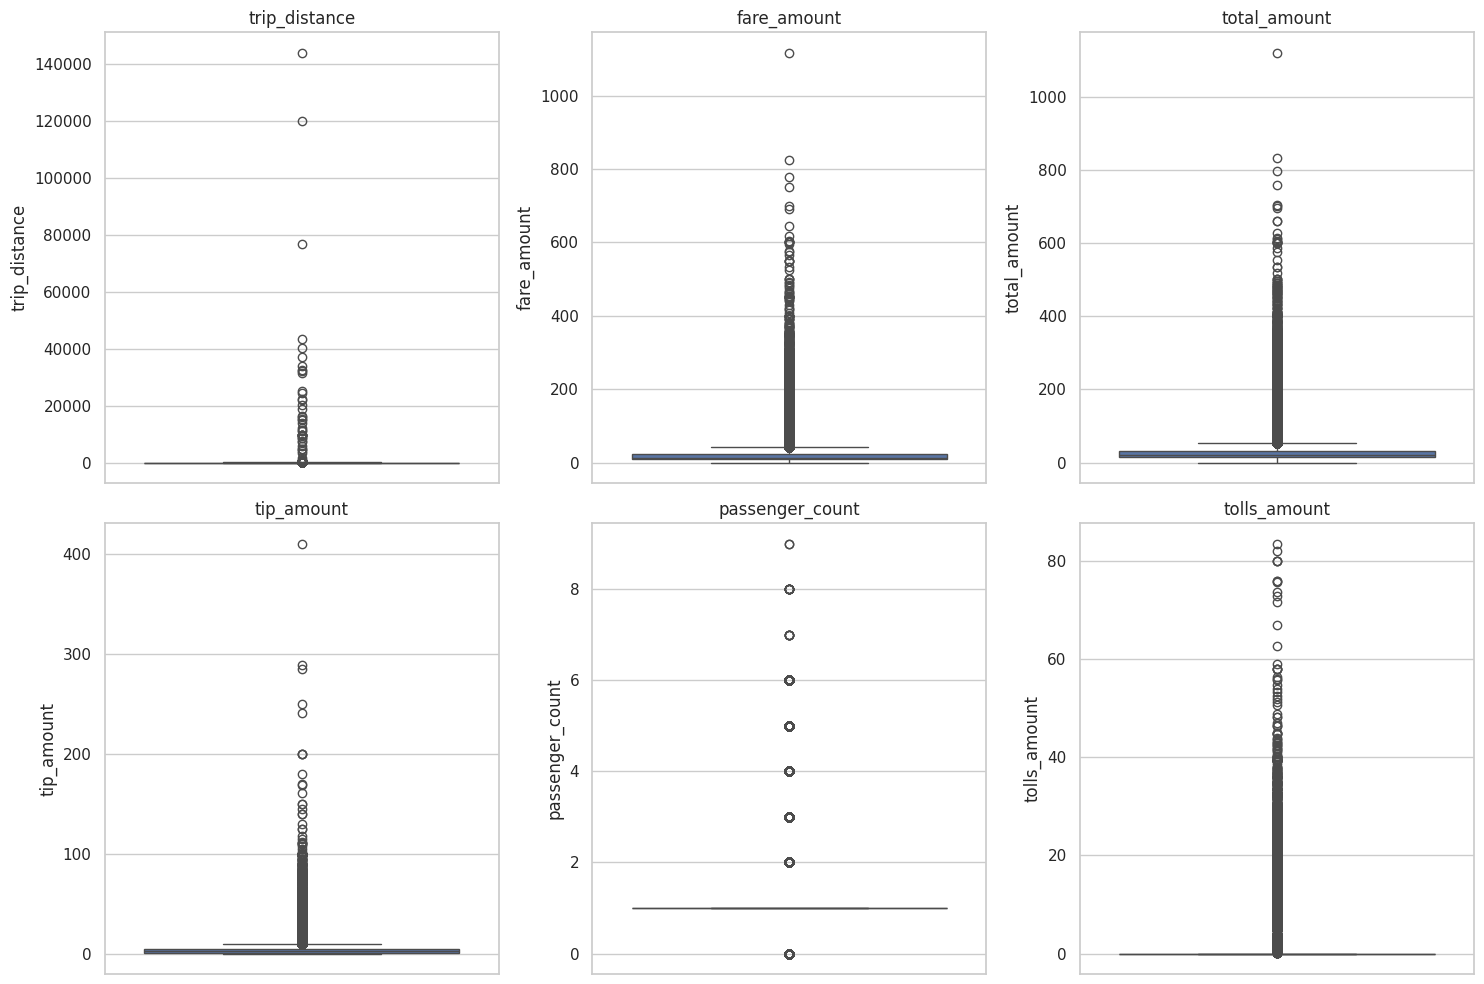

In [96]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [97]:
# remove passenger_count > 6
mask0=df['passenger_count'] > 6
print(mask0.sum(), "rows to remove: where passenger_count is > 6")
df=df[~mask0]
print(mask0.sum(), "rows removed")

18 rows to remove: where passenger_count is > 6
18 rows removed


In [98]:
# Continue with outlier handling
# 1) trip_distance nearly 0 AND fare_amount > 300
mask1 = (df['trip_distance'] < 0.1) & (df['fare_amount'] > 300)
print(mask1.sum(), "rows to remove (near-zero distance, high fare)")
df = df[~mask1]
print(mask1.sum(), "rows removed for (near-zero distance, high fare)")
# 2) trip_distance = 0 AND fare_amount = 0 AND different zones
mask2 = (
    (df['trip_distance'] == 0) &
    (df['fare_amount'] == 0) &
    (df['PULocationID'] != df['DOLocationID'])
)
print(mask2.sum(), "rows to remove (zero distance & fare but different zones)")
df = df[~mask2]
print(mask2.sum(), "rows removed for (zero distance & fare but different zones)")

# 3) trip_distance > 250 miles
mask3 = df['trip_distance'] > 250
print(mask3.sum(), "rows to remove (trip_distance > 250 miles)")
df = df[~mask3]
print(mask3.sum(), "rows removed for (trip_distance > 250 miles)")

# 4) payment_type = 0 (invalid)
mask4 = df['payment_type'] == 0
print(f"Found {mask4.sum()} rows with undefined payment_type=0.")

# Replace 0 with 5 (Unknown)
df.loc[mask4, 'payment_type'] = 5

print("Successfully replaced undefined payment types with 5 (Unknown).")

# Verify the fix by checking the unique values in the column
print("Current payment types in dataset:", df['payment_type'].unique())



35 rows to remove (near-zero distance, high fare)
35 rows removed for (near-zero distance, high fare)
81 rows to remove (zero distance & fare but different zones)
81 rows removed for (zero distance & fare but different zones)
44 rows to remove (trip_distance > 250 miles)
44 rows removed for (trip_distance > 250 miles)
Found 64929 rows with undefined payment_type=0.
Successfully replaced undefined payment types with 5 (Unknown).
Current payment types in dataset: [1 5 2 4 3]


In [99]:
# Do any columns need standardising?
# No, columns do not need standardizing for EDA. Converting metrics like fare_amount or trip_distance into abstract scales
# ruins their real-world interpretability (dollars, miles), making it difficult to draw actionable business insights.

## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [100]:
df.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'store_and_fwd_flag',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'airport_fee_combined']

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`:
* `tpep_pickup_datetime`:
* `tpep_dropoff_datetime`:
* `passenger_count`:
* `trip_distance`:
* `RatecodeID`:
* `PULocationID`:
* `DOLocationID`:
* `payment_type`:
* `pickup_hour`:
* `trip_duration`:


The following monetary parameters belong in the same category, is it categorical or numerical?


* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge`
* `airport_fee`

##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

In [101]:
# Convert datetime columns to datetime data type
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1896222 entries, 0 to 1896399
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[ns]
 2   tpep_dropoff_datetime  datetime64[ns]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee_combined   floa

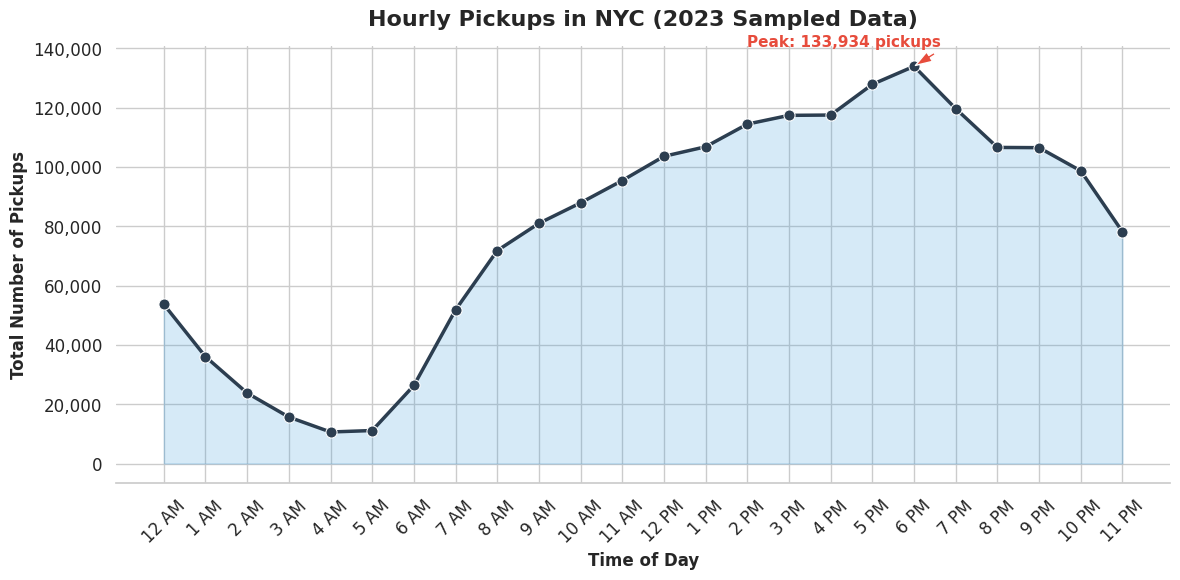

In [102]:
# Find and show the hourly trends in taxi pickups
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour

hourly_trend = df.groupby('pickup_hour').size().reset_index(name='pickup_count')

sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.1)

plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=hourly_trend,
    x='pickup_hour',
    y='pickup_count',
    marker='o',
    linewidth=2.5,
    markersize=8,
    color='#2c3e50'
)

plt.fill_between(hourly_trend['pickup_hour'], hourly_trend['pickup_count'], alpha=0.2, color='#3498db')

hours = list(range(24))
hour_labels = [f"{h%12 if h%12!=0 else 12} {'AM' if h<12 else 'PM'}" for h in hours]
plt.xticks(hours, hour_labels, rotation=45)

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: format(int(x), ',')))

plt.title('Hourly Pickups in NYC (2023 Sampled Data)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Time of Day', fontsize=12, fontweight='bold')
plt.ylabel('Total Number of Pickups', fontsize=12, fontweight='bold')

peak_row = hourly_trend.loc[hourly_trend['pickup_count'].idxmax()]

text_x_offset = peak_row['pickup_hour'] - 4 if peak_row['pickup_hour'] > 4 else peak_row['pickup_hour'] + 2

plt.annotate(
    f"Peak: {int(peak_row['pickup_count']):,} pickups",
    xy=(peak_row['pickup_hour'], peak_row['pickup_count']),
    xytext=(text_x_offset, peak_row['pickup_count'] * 1.05),
    arrowprops=dict(facecolor='#e74c3c', shrink=0.05, width=2, headwidth=8),
    fontsize=11,
    fontweight='bold',
    color='#e74c3c'
)

sns.despine(left=True)
plt.tight_layout()
plt.show()


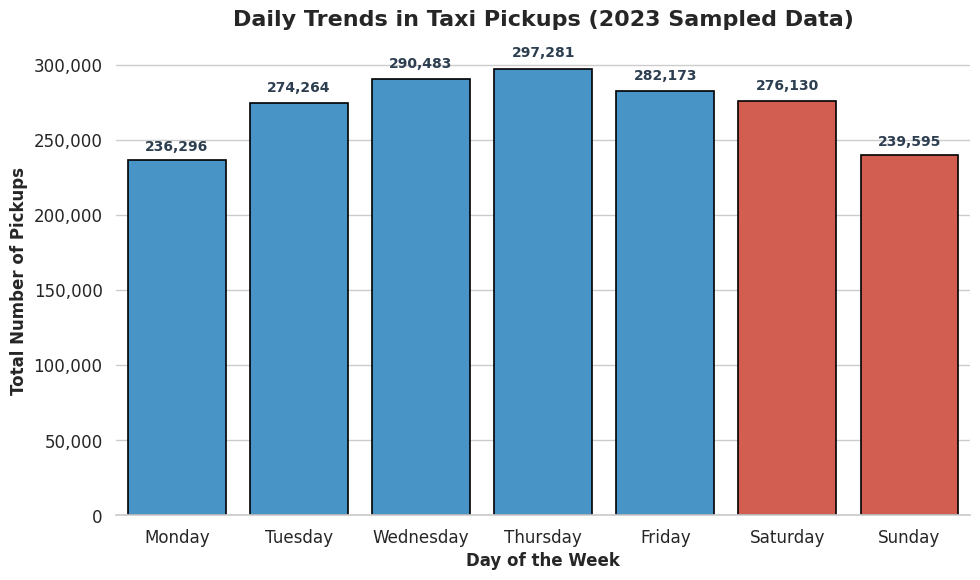

In [103]:
# Find and show the daily trends in taxi pickups (days of the week)

df['pickup_day'] = df['tpep_pickup_datetime'].dt.day_name()
daily_pickups = df.groupby('pickup_day').size()

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_pickups = daily_pickups.reindex(days_order)

sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.1)

plt.figure(figsize=(10, 6))

colors = ['#3498db']*5 + ['#e74c3c']*2

ax = sns.barplot(
    x=daily_pickups.index,
    y=daily_pickups.values,
    palette=colors,
    edgecolor='black',
    linewidth=1.2
)

for i, v in enumerate(daily_pickups.values):
    ax.text(
        i,
        v + (v * 0.02),
        f"{int(v):,}",
        ha='center',
        va='bottom',
        fontweight='bold',
        color='#2c3e50',
        fontsize=10
    )

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: format(int(x), ',')))

plt.title('Daily Trends in Taxi Pickups (2023 Sampled Data)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Day of the Week', fontsize=12, fontweight='bold')
plt.ylabel('Total Number of Pickups', fontsize=12, fontweight='bold')

sns.despine(left=True)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

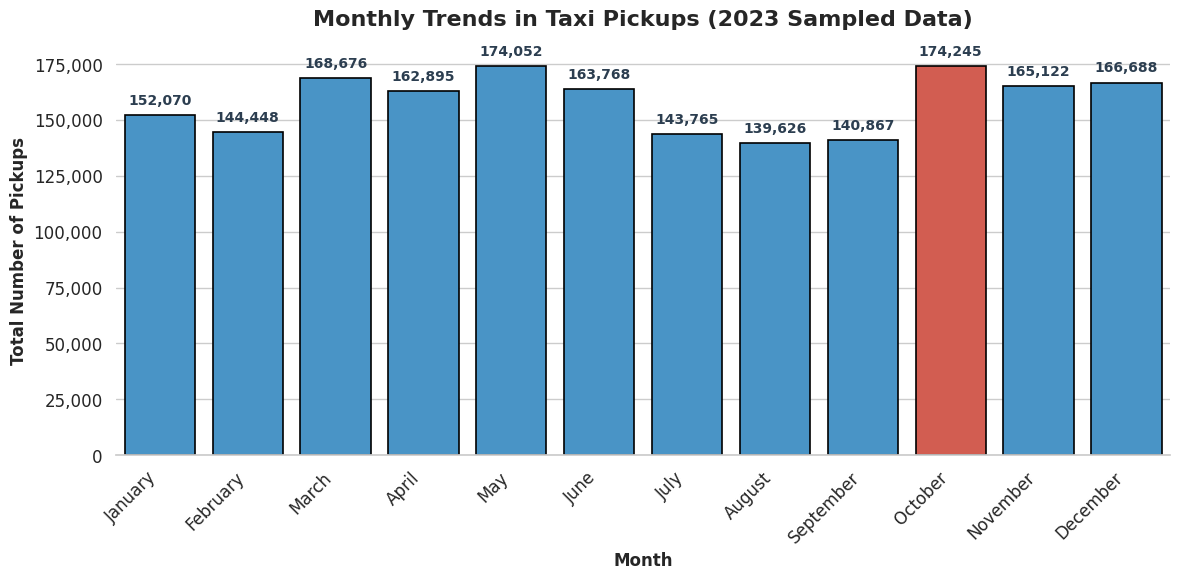

In [104]:
# Show the monthly trends in pickups

df['pickup_month'] = df['tpep_pickup_datetime'].dt.month_name()
monthly_pickups = df.groupby('pickup_month').size()

months_order = ['January', 'February', 'March', 'April', 'May', 'June',
                'July', 'August', 'September', 'October', 'November', 'December']
monthly_pickups = monthly_pickups.reindex(months_order).fillna(0)

sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.1)

plt.figure(figsize=(12, 6))

max_val = monthly_pickups.max()
colors = ['#e74c3c' if val == max_val else '#3498db' for val in monthly_pickups.values]

ax = sns.barplot(
    x=monthly_pickups.index,
    y=monthly_pickups.values,
    palette=colors,
    edgecolor='black',
    linewidth=1.2
)

for i, v in enumerate(monthly_pickups.values):
    if v > 0:
        ax.text(
            i,
            v + (max_val * 0.02),
            f"{int(v):,}",
            ha='center',
            va='bottom',
            fontweight='bold',
            color='#2c3e50',
            fontsize=10
        )

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: format(int(x), ',')))

plt.title('Monthly Trends in Taxi Pickups (2023 Sampled Data)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Month', fontsize=12, fontweight='bold')
plt.ylabel('Total Number of Pickups', fontsize=12, fontweight='bold')

sns.despine(left=True)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [105]:
# Analyse the above parameters
col_to_analyse = ['fare_amount','tip_amount','total_amount','trip_distance']
df_analysis = pd.DataFrame(columns = ['Zero_Count','Negative_Count'])
for col in col_to_analyse:
    df_analysis.loc[col,'Zero_Count'] = df[df[col] == 0][col].count()
    df_analysis.loc[col,'Negative_Count'] = df[df[col] < 0][col].count()
df_analysis


,Zero_Count,Negative_Count
fare_amount,593,0
tip_amount,434692,0
total_amount,269,0
trip_distance,36390,0


Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

In [106]:
# Create a df with non zero entries for the selected parameters.

filtered_df = df.copy()

# Filtered out zero values ONLY for parameters that must logically be > 0
filtered_df = filtered_df[
    (filtered_df['fare_amount'] != 0) &
    (filtered_df['total_amount'] != 0) &
    (filtered_df['trip_distance'] != 0)
]

print(f"Original shape: {df.shape}")
print(f"Filtered shape: {filtered_df.shape}")


Original shape: (1896222, 22)
Filtered shape: (1859494, 22)


**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

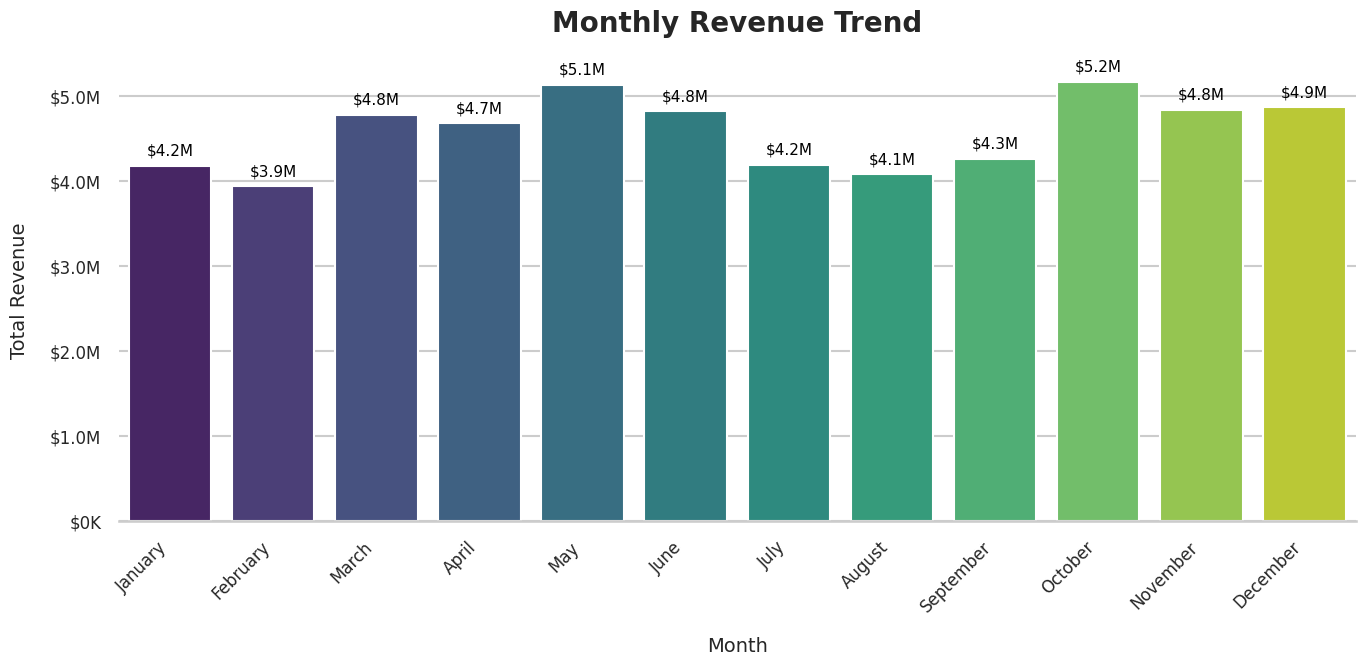

In [107]:
# Group data by month and analyse monthly revenue
if 'pickup_month' not in df.columns:
    df['pickup_month'] = df['tpep_pickup_datetime'].dt.month_name()

monthly_revenue = df.groupby('pickup_month')['total_amount'].sum()
months_order = ['January', 'February', 'March', 'April', 'May', 'June',
                'July', 'August', 'September', 'October', 'November', 'December']
monthly_revenue = monthly_revenue.reindex(months_order)

sns.set_theme(style="whitegrid", context="talk")
plt.figure(figsize=(14, 7))

ax = sns.barplot(
    x=monthly_revenue.index,
    y=monthly_revenue.values,
    palette="viridis",
    hue=monthly_revenue.index,
    legend=False
)

formatter = FuncFormatter(lambda x, pos: f'${x*1e-6:.1f}M' if x >= 1e6 else f'${x*1e-3:.0f}K')
ax.yaxis.set_major_formatter(formatter)

for p in ax.patches:
    height = p.get_height()
    if pd.notnull(height) and height > 0:
        label = f'${height*1e-6:.1f}M' if height >= 1e6 else f'${height*1e-3:.0f}K'
        ax.annotate(label,
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=11, color='black',
                    xytext=(0, 5), textcoords='offset points')

plt.title('Monthly Revenue Trend', fontsize=20, pad=20, fontweight='bold')
plt.xlabel('Month', fontsize=14, labelpad=15)
plt.ylabel('Total Revenue', fontsize=14, labelpad=15)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)

sns.despine(left=True)
plt.tight_layout()
plt.show()

**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

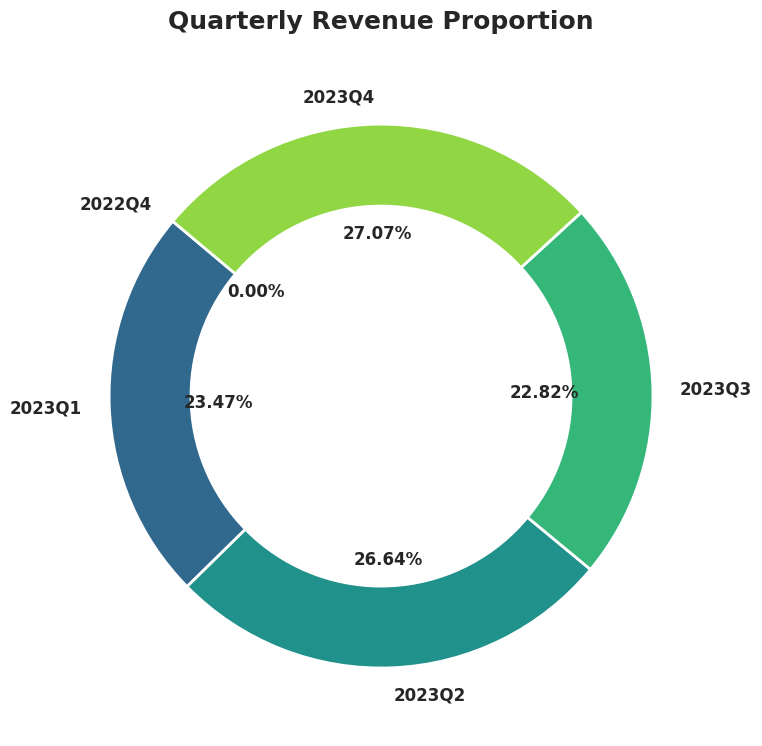

In [108]:
# Calculate proportion of each quarter
quarterly_revenue = df.groupby(df['tpep_pickup_datetime'].dt.to_period('Q'))['total_amount'].sum()
quarterly_proportion = (quarterly_revenue / quarterly_revenue.sum()) * 100

plt.figure(figsize=(8, 8))
colors = sns.color_palette("viridis", len(quarterly_proportion))

plt.pie(
    quarterly_proportion,
    labels=quarterly_proportion.index.astype(str),
    autopct='%1.2f%%',
    startangle=140,
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)

centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Quarterly Revenue Proportion', fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

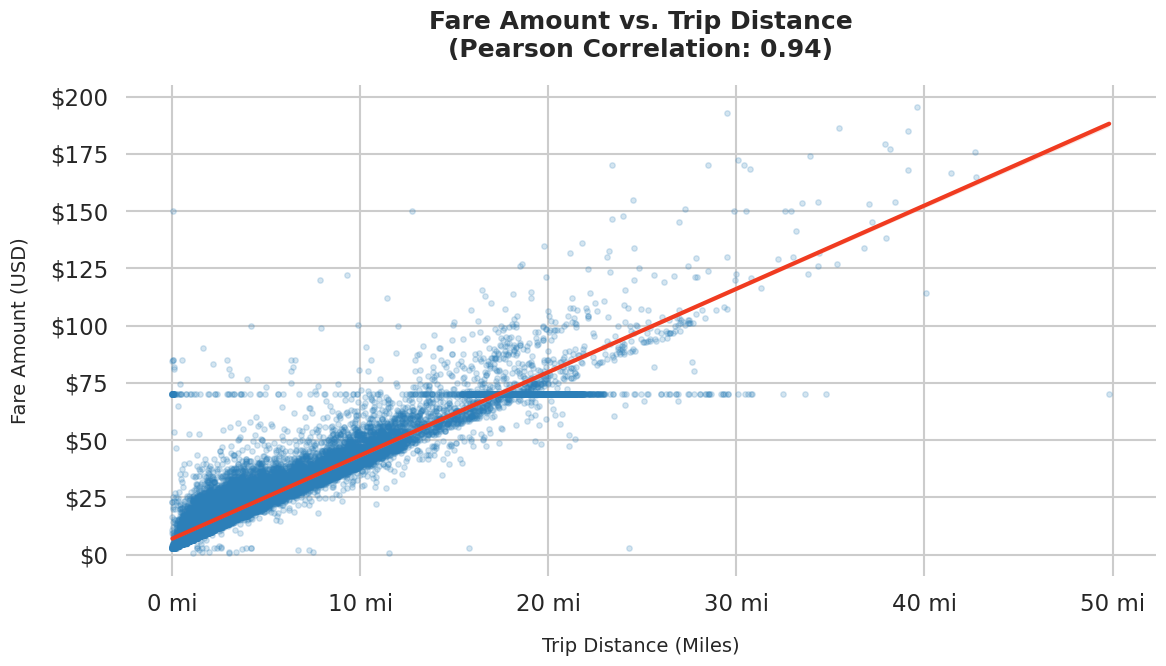

Correlation between trip distance and fare amount: 0.94


In [109]:
# Show how trip fare is affected by distance
subset_df = df[df['trip_distance'] > 0]

correlation = subset_df['trip_distance'].corr(subset_df['fare_amount'])

plot_df = subset_df[
    (subset_df['trip_distance'] < 50) &
    (subset_df['fare_amount'] < 200) &
    (subset_df['fare_amount'] > 0)
]
plot_df = plot_df.sample(n=min(len(plot_df), 50000), random_state=42)

sns.set_theme(style="whitegrid", context="talk")
plt.figure(figsize=(12, 7))

ax = sns.regplot(
    x='trip_distance',
    y='fare_amount',
    data=plot_df,
    scatter_kws={'alpha': 0.2, 's': 15, 'color': '#2c7fb8'},
    line_kws={'color': '#f03b20', 'linewidth': 3}
)

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${x:,.0f}'))
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x:,.0f} mi'))

plt.title(f'Fare Amount vs. Trip Distance\n(Pearson Correlation: {correlation:.2f})',
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Trip Distance (Miles)', fontsize=14, labelpad=15)
plt.ylabel('Fare Amount (USD)', fontsize=14, labelpad=15)

sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

print(f"Correlation between trip distance and fare amount: {correlation:.2f}")


**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

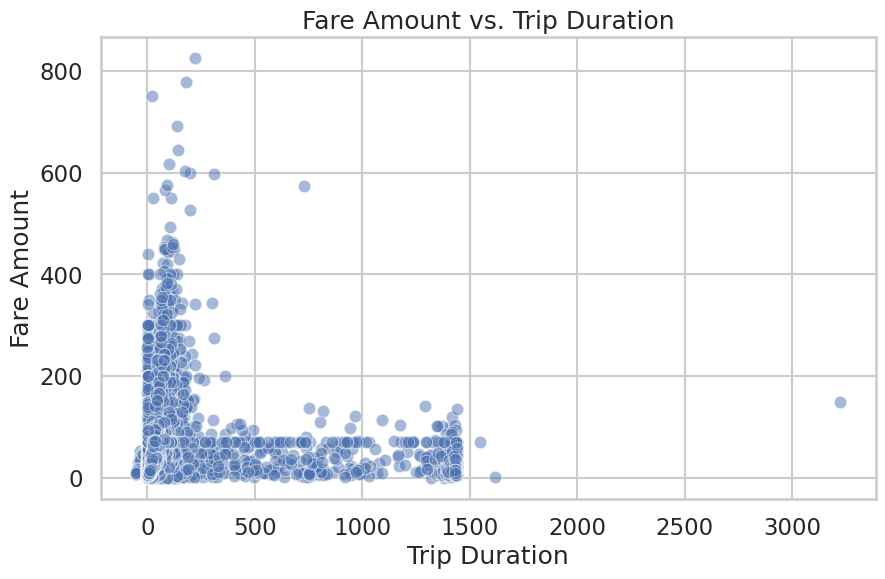

Correlation between trip duration and fare amount: 0.27


In [110]:
# Show relationship between fare and trip duration
df['trip_duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60

plt.figure(figsize=(10, 6))
sns.scatterplot(x='trip_duration', y='fare_amount', data=df, alpha=0.5)
plt.title('Fare Amount vs. Trip Duration')
plt.xlabel('Trip Duration')
plt.ylabel('Fare Amount')
plt.grid(True)
plt.show()

correlation = df['trip_duration'].corr(df['fare_amount'])
print(f"Correlation between trip duration and fare amount: {correlation:.2f}")


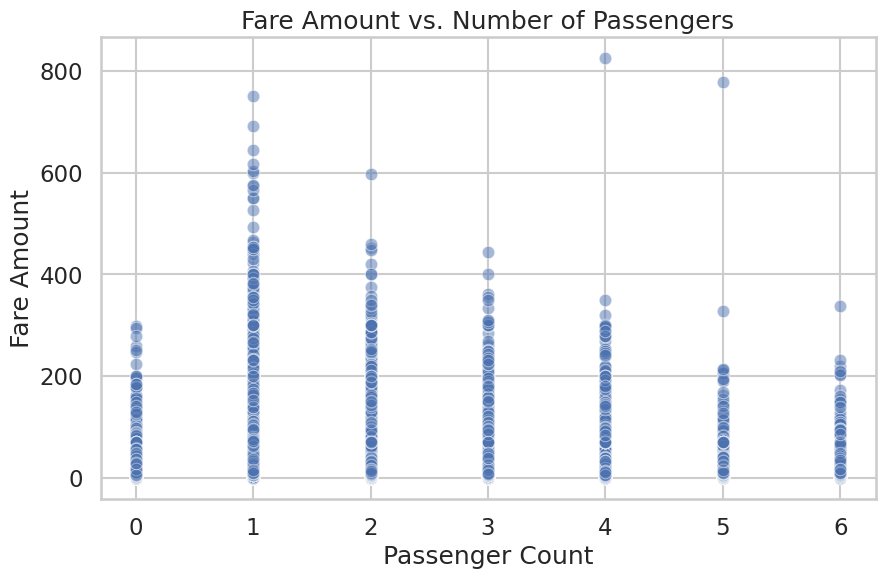

Correlation between passenger count and fare amount: 0.05


In [111]:
# Show relationship between fare and number of passengers
plt.figure(figsize=(10, 6))
sns.scatterplot(x='passenger_count', y='fare_amount', data=df, alpha=0.5)
plt.title('Fare Amount vs. Number of Passengers')
plt.xlabel('Passenger Count')
plt.ylabel('Fare Amount')
plt.grid(True)
plt.show()

correlation = df['passenger_count'].corr(df['fare_amount'])
print(f"Correlation between passenger count and fare amount: {correlation:.2f}")



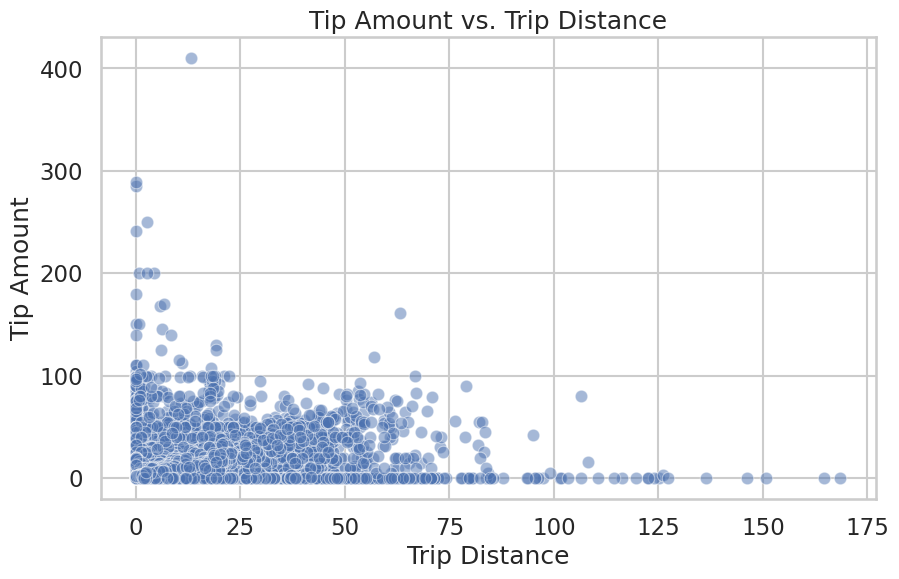

Correlation between trip distance and tip amount: 0.57


In [112]:
# Show relationship between tip and trip distance
plt.figure(figsize=(10, 6))
sns.scatterplot(x='trip_distance', y='tip_amount', data=df, alpha=0.5)
plt.title('Tip Amount vs. Trip Distance')
plt.xlabel('Trip Distance')
plt.ylabel('Tip Amount')
plt.grid(True)
plt.show()

correlation = df['trip_distance'].corr(df['tip_amount'])
print(f"Correlation between trip distance and tip amount: {correlation:.2f}")


**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

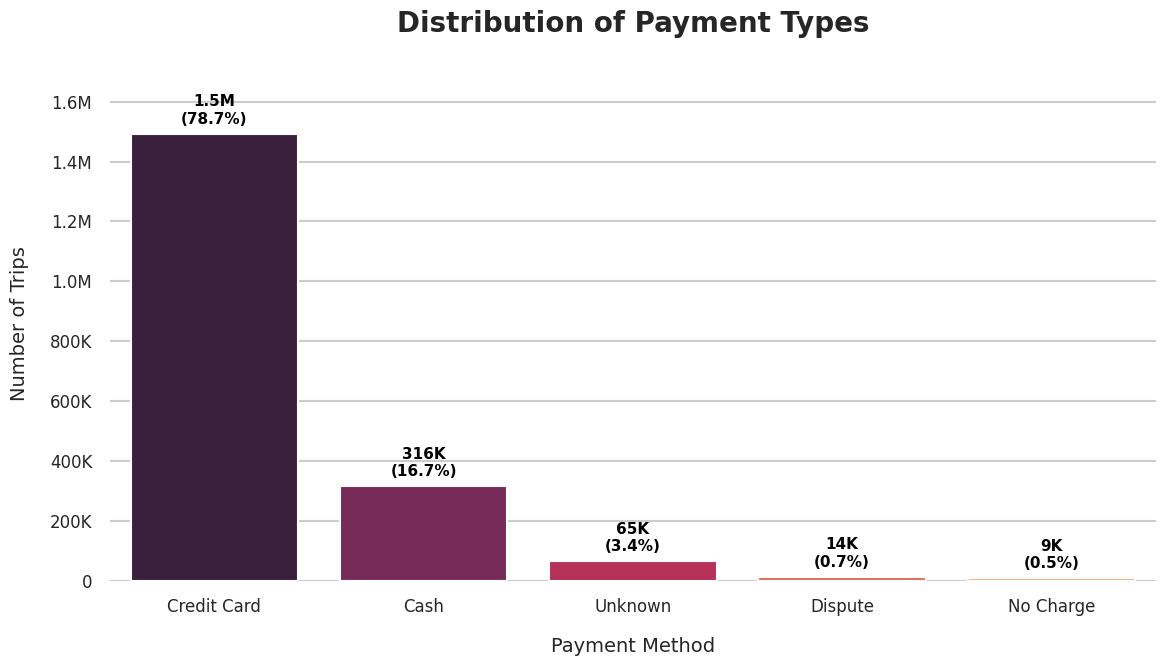

In [113]:
# Analyse the distribution of different payment types (payment_type).
payment_type_dict = {1: 'Credit Card', 2: 'Cash', 3: 'No Charge', 4: 'Dispute', 5: 'Unknown', 6: 'Voided Trip'}

payment_counts = df['payment_type'].map(payment_type_dict).value_counts().reset_index()
payment_counts.columns = ['PaymentType', 'Count']

sns.set_theme(style="whitegrid", context="talk")
plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=payment_counts,
    x='PaymentType',
    y='Count',
    palette="rocket",
    hue='PaymentType',
    legend=False
)

formatter = FuncFormatter(lambda x, pos: f'{x*1e-6:.1f}M' if x >= 1e6 else (f'{x*1e-3:.0f}K' if x >= 1e3 else f'{x:.0f}'))
ax.yaxis.set_major_formatter(formatter)

total_trips = payment_counts['Count'].sum()
for p in ax.patches:
    height = p.get_height()
    if pd.notnull(height) and height > 0:
        percentage = f'{(height/total_trips)*100:.1f}%'

        if height >= 1e6:
            label = f'{height*1e-6:.1f}M\n({percentage})'
        elif height >= 1e3:
            label = f'{height*1e-3:.0f}K\n({percentage})'
        else:
            label = f'{height:.0f}\n({percentage})'

        ax.annotate(label,
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=11, color='black', fontweight='bold',
                    xytext=(0, 5), textcoords='offset points')

plt.ylim(0, payment_counts['Count'].max() * 1.15)

plt.title('Distribution of Payment Types', fontsize=20, pad=25, fontweight='bold')
plt.xlabel('Payment Method', fontsize=14, labelpad=15)
plt.ylabel('Number of Trips', fontsize=14, labelpad=15)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()



- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [114]:
!pip install geopandas

**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [115]:
import geopandas as gpd
# Read the shapefile using geopandas
zones = gpd.read_file('/content/drive/MyDrive/Assignments/EDA/data_NYC_Taxi/taxi_zones/taxi_zones.shp') # read the .shp file using gpd
zones.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 12.5+ KB
None


<Axes: >

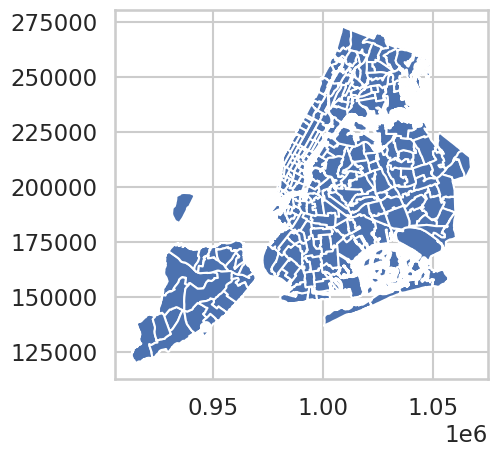

In [116]:
print(zones.info())
zones.plot()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [117]:
# Merge zones and trip records using locationID and PULocationID
merged_df = pd.merge(df, zones, left_on='PULocationID', right_on='LocationID', how='left')
merged_df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,pickup_day,pickup_month,trip_duration,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,2,2022-12-31 23:36:04,2022-12-31 23:43:31,1.0,1.69,1.0,N,43,141,1,...,Saturday,December,7.450000,43.0,0.099739,0.000380,Central Park,43.0,Manhattan,"POLYGON ((991852.973 217950.807, 991725.244 21..."
1,1,2023-01-01 00:59:47,2023-01-01 01:23:42,1.0,0.00,1.0,N,68,45,5,...,Sunday,January,23.916667,68.0,0.049337,0.000111,East Chelsea,68.0,Manhattan,"POLYGON ((983690.405 209040.369, 983550.612 20..."
2,2,2023-01-01 00:18:34,2023-01-01 00:23:55,1.0,0.99,1.0,N,144,211,2,...,Sunday,January,5.350000,144.0,0.027620,0.000047,Little Italy/NoLiTa,144.0,Manhattan,"POLYGON ((985411.76 200369.518, 985342.573 200..."
3,2,2023-01-01 00:32:27,2023-01-01 00:37:01,2.0,0.92,1.0,N,79,107,1,...,Sunday,January,4.566667,79.0,0.042625,0.000108,East Village,79.0,Manhattan,"POLYGON ((988746.067 202151.955, 988733.885 20..."
4,1,2023-01-01 00:26:11,2023-01-01 00:40:21,2.0,2.30,1.0,Y,48,238,1,...,Sunday,January,14.166667,48.0,0.043747,0.000094,Clinton East,48.0,Manhattan,"POLYGON ((986694.313 214463.846, 986568.184 21..."


**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [118]:
# Group data by location and calculate the number of trips
trip_counts = merged_df.groupby('PULocationID').size().reset_index(name='TripCount')
trip_counts.head()

,PULocationID,TripCount
0,1,235
1,2,2
2,3,44
3,4,2312
4,5,25


**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [119]:
# Merge trip counts back to the zones GeoDataFrame
trip_zones_df = pd.merge(zones, trip_counts, left_on='LocationID', right_on='PULocationID', how='left')
trip_zones_df.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,PULocationID,TripCount
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",1.0,235.0
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343...",2.0,2.0
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2...",3.0,44.0
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20...",4.0,2312.0
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144...",5.0,25.0


The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

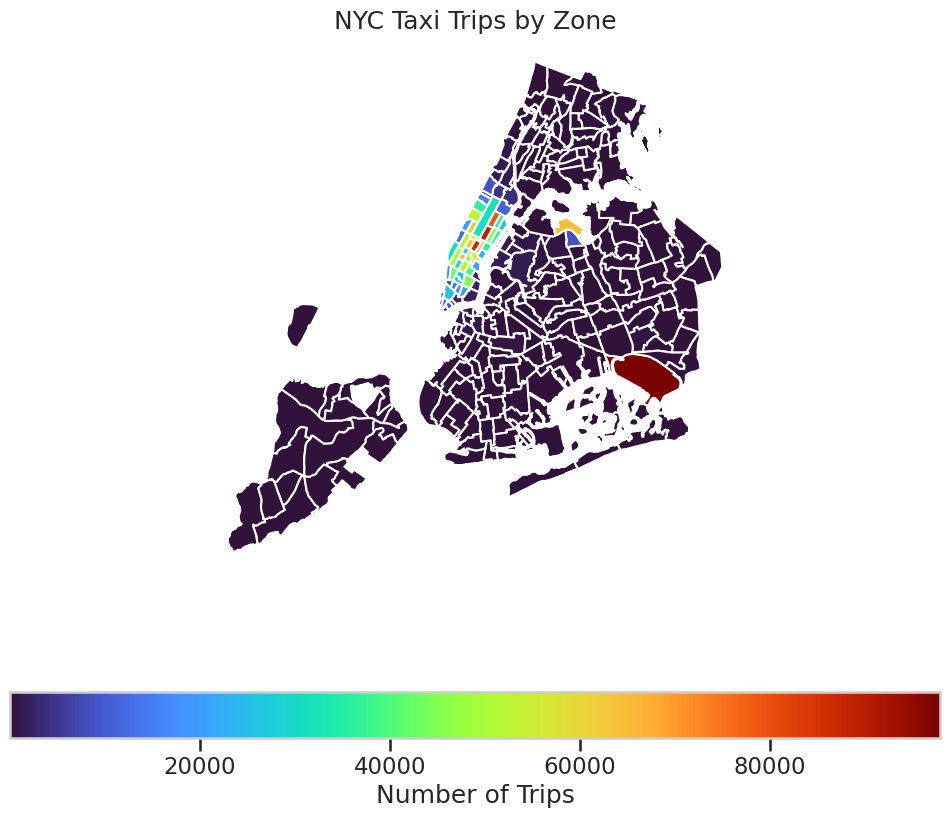

In [120]:
# Define figure and axis
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
trip_zones_df.plot(
    column='TripCount',
    ax=ax,
    legend=True,
    legend_kwds={
        'label': "Number of Trips",
        'orientation': "horizontal"
    },
    cmap='turbo')
# Plot the map and display it
ax.set_title("NYC Taxi Trips by Zone")
plt.axis('off')
plt.show()

In [121]:
# can you try displaying the zones DF sorted by the number of trips?
trip_zones_df.sort_values(by='TripCount', ascending=False).head()
trip_zones_df.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,PULocationID,TripCount
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",1.0,235.0
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343...",2.0,2.0
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2...",3.0,44.0
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20...",4.0,2312.0
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144...",5.0,25.0


Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

In [122]:
# Find routes which have the slowest speeds at different times of the day
route_df = df[['PULocationID', 'DOLocationID', 'trip_distance', 'tpep_pickup_datetime', 'tpep_dropoff_datetime']].copy()
route_df['hour'] = route_df['tpep_pickup_datetime'].dt.hour
route_df['trip_time_in_hrs'] = (route_df['tpep_dropoff_datetime'] - route_df['tpep_pickup_datetime']).dt.total_seconds() / 3600
route_df = route_df[(route_df['trip_time_in_hrs'] > 0) & (route_df['trip_distance'] > 0)]
route_df['trip_speed'] = route_df['trip_distance'].astype(float) / route_df['trip_time_in_hrs'].astype(float)
grouped_route_df = route_df.groupby(['PULocationID', 'DOLocationID', 'hour'])['trip_speed'].mean().reset_index()
slowest_routes = grouped_route_df.sort_values(by='trip_speed').head(10)
print(slowest_routes)


        PULocationID  DOLocationID  hour  trip_speed
99007            223           223     4    0.000989
94075            194           194    15    0.002741
71839            148           226    12    0.007007
17285             61           145    14    0.018987
94033            193           264    10    0.020000
518                4           142    10    0.020642
98102            215           215    16    0.020690
33443             90            83    12    0.025806
29034             80            68    17    0.036727
117034           237           264     2    0.050011


How does identifying high-traffic, high-demand routes help us?

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

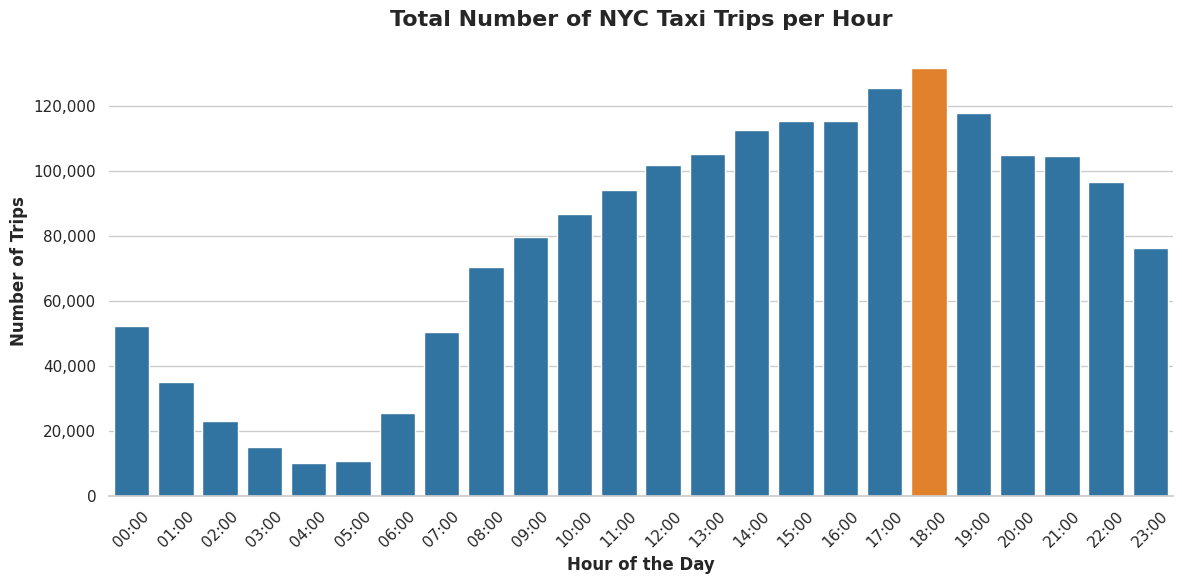

Busiest hour: 18:00
Number of Trips in Busiest hour: 131,546


In [123]:
# Visualise the number of trips per hour and find the busiest hour
hourly_trips = route_df['hour'].value_counts().sort_index()
busiest_hour = hourly_trips.idxmax()

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

colors = ['#ff7f0e' if hour == busiest_hour else '#1f77b4' for hour in hourly_trips.index]

ax = sns.barplot(x=hourly_trips.index, y=hourly_trips.values, palette=colors)

plt.title('Total Number of NYC Taxi Trips per Hour', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Hour of the Day', fontsize=12, fontweight='bold')
plt.ylabel('Number of Trips', fontsize=12, fontweight='bold')

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: format(int(x), ',')))
ax.set_xticklabels([f"{int(h):02d}:00" for h in hourly_trips.index], rotation=45)

sns.despine(left=True)
plt.tight_layout()
plt.show()

print(f"Busiest hour: {busiest_hour}:00")
print(f"Number of Trips in Busiest hour: {hourly_trips[busiest_hour]:,}")


Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [124]:
# Scale up the number of trips

# Fill in the value of your sampling fraction and use that to scale up the numbers
sample_fraction = 0.05
trip_counts = route_df['hour'].value_counts().sort_index()
top5_hours = trip_counts.sort_values(ascending=False).head(5)
scaled_top5 = (top5_hours / sample_fraction).astype(int)
scaled_top5



,count
hour,
18,2630920
17,2510820
19,2352620
16,2308100
15,2307940


**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

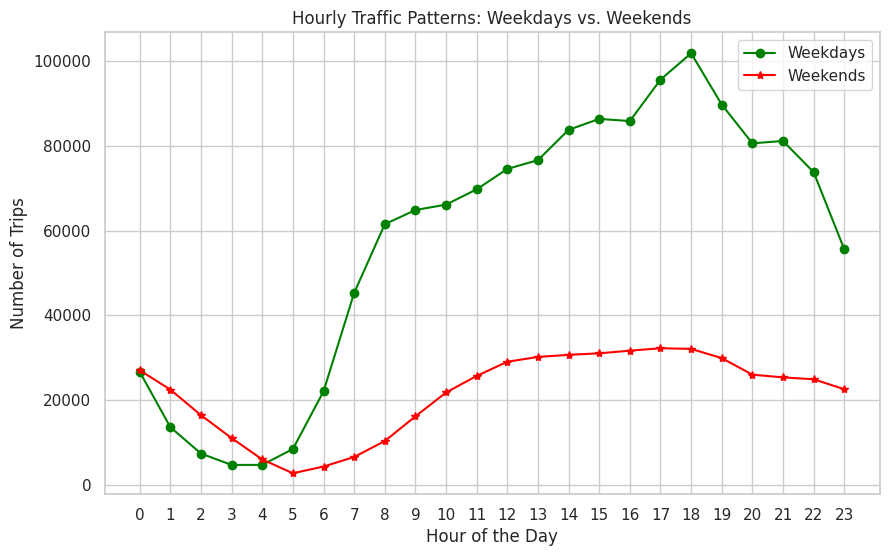

In [125]:
# Compare traffic trends for the week days and weekends
df['hour'] = df['tpep_pickup_datetime'].dt.hour
df_weekend = df[df['pickup_day'].isin(['Saturday', 'Sunday'])]
df_weekday = df[~df['pickup_day'].isin(['Saturday', 'Sunday'])]
weekday_hourly_counts = df_weekday.groupby('hour').size()
weekend_hourly_counts = df_weekend.groupby('hour').size()
plt.figure(figsize=(10, 6))
plt.plot(weekday_hourly_counts.index, weekday_hourly_counts.values, label='Weekdays', marker='o', color='green')
plt.plot(weekend_hourly_counts.index, weekend_hourly_counts.values, label='Weekends', marker='*', color='red')
plt.title('Hourly Traffic Patterns: Weekdays vs. Weekends')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Trips')
plt.xticks(range(24))
plt.legend()
plt.grid(True)
plt.show()


What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

,LocationID,Total_Trips,zone
0,132,97953,JFK Airport
1,237,88916,Upper East Side South
2,161,87360,Midtown Center
3,236,79204,Upper East Side North
4,162,67152,Midtown East
5,186,64938,Penn Station/Madison Sq West
6,138,64579,LaGuardia Airport
7,230,62798,Times Sq/Theatre District
8,142,61914,Lincoln Square East
9,170,56188,Murray Hill


,LocationID,Total_Trips,zone
0,236,83459,Upper East Side North
1,237,79686,Upper East Side South
2,161,73436,Midtown Center
3,230,57645,Times Sq/Theatre District
4,170,55657,Murray Hill
5,162,53342,Midtown East
6,239,53149,Upper West Side South
7,142,53019,Lincoln Square East
8,141,49725,Lenox Hill West
9,68,47984,East Chelsea


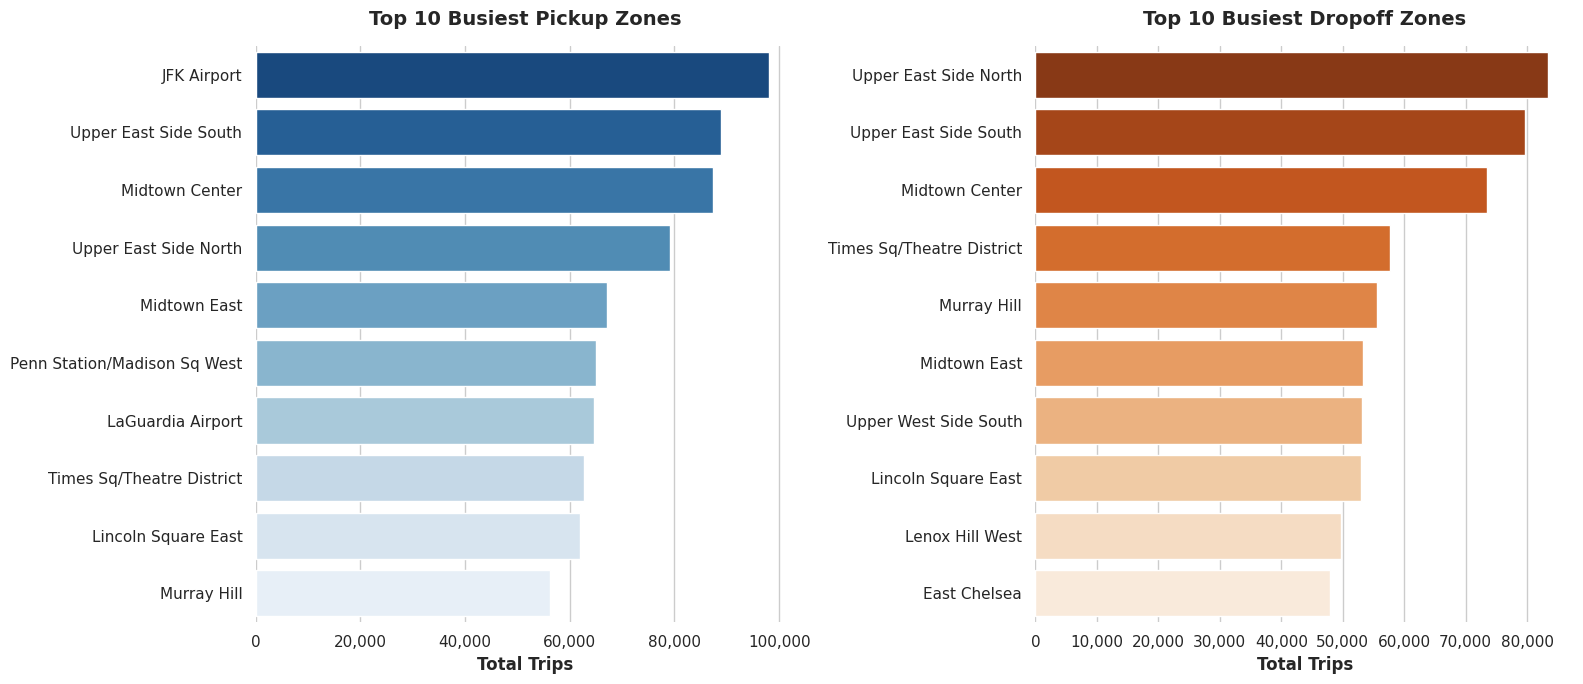

In [126]:
from IPython.display import display

pickup_df = df['PULocationID'].value_counts().head(10).reset_index()
pickup_df.columns = ['LocationID', 'Total_Trips']
pickup_df = pickup_df.merge(zones[['LocationID', 'zone']], on='LocationID', how='left')

drop_df = df['DOLocationID'].value_counts().head(10).reset_index()
drop_df.columns = ['LocationID', 'Total_Trips']
drop_df = drop_df.merge(zones[['LocationID', 'zone']], on='LocationID', how='left')

display(pickup_df.style.set_caption("Top 10 Pickup Zones").background_gradient(subset=['Total_Trips'], cmap='Blues'))
display(drop_df.style.set_caption("Top 10 Dropoff Zones").background_gradient(subset=['Total_Trips'], cmap='Oranges'))

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.barplot(data=pickup_df, x='Total_Trips', y='zone', ax=axes[0], palette='Blues_r')
axes[0].set_title('Top 10 Busiest Pickup Zones', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Total Trips', fontsize=12, fontweight='bold')
axes[0].set_ylabel('')
axes[0].xaxis.set_major_formatter(FuncFormatter(lambda x, p: format(int(x), ',')))

sns.barplot(data=drop_df, x='Total_Trips', y='zone', ax=axes[1], palette='Oranges_r')
axes[1].set_title('Top 10 Busiest Dropoff Zones', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Total Trips', fontsize=12, fontweight='bold')
axes[1].set_ylabel('')
axes[1].xaxis.set_major_formatter(FuncFormatter(lambda x, p: format(int(x), ',')))

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()


**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

,LocationID,Pickup_Trips,Dropoff_Trips,zone,ratio
48,70,8442,1060.000000,East Elmhurst,7.96
0,132,97953,23222.000000,JFK Airport,4.22
6,138,64579,24600.000000,LaGuardia Airport,2.63
5,186,64938,41516.000000,Penn Station/Madison Sq West,1.56
31,114,25261,18159.000000,Greenwich Village South,1.39
25,43,31444,23068.000000,Central Park,1.36
18,249,42297,31586.000000,West Village,1.34
4,162,67152,53342.000000,Midtown East,1.26
26,100,31209,25952.000000,Garment District,1.20
2,161,87360,73436.000000,Midtown Center,1.19


,LocationID,Pickup_Trips,Dropoff_Trips,zone,ratio
102,1,235,5551.000000,Newark Airport,0.04
94,243,288,3302.000000,Washington Heights North,0.09
83,112,380,4228.000000,Greenpoint,0.09
129,92,126,1316.000000,Flushing,0.10
96,95,283,2379.000000,Forest Hills,0.12
99,17,255,2087.000000,Bedford,0.12
106,189,216,1745.000000,Prospect Heights,0.12
98,37,276,2191.000000,Bushwick South,0.13
86,49,342,2688.000000,Clinton Hill,0.13
74,181,638,4997.000000,Park Slope,0.13


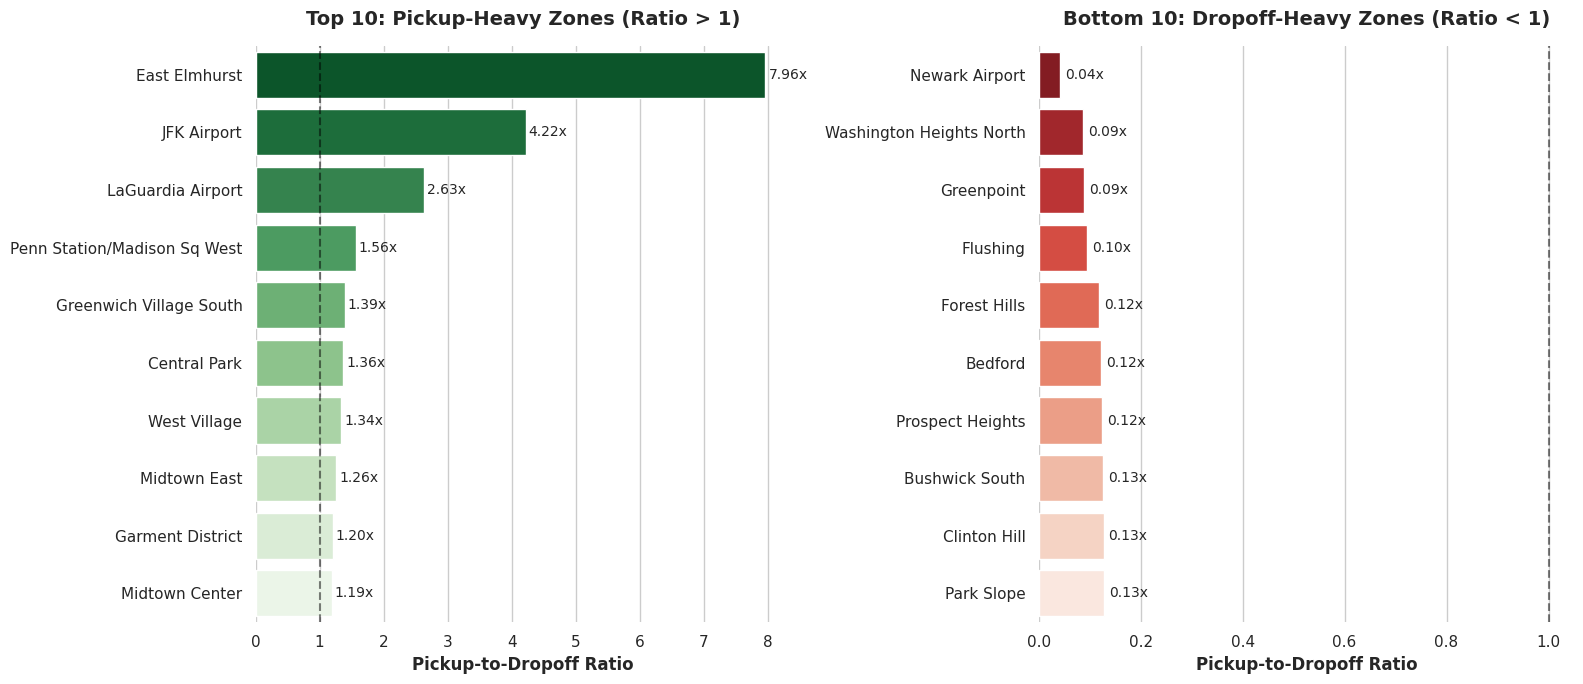

In [127]:
# Find the top 10 and bottom 10 pickup/dropoff ratios

pickup_df = df['PULocationID'].value_counts().reset_index()
dropoff_df = df['DOLocationID'].value_counts().reset_index()
pickup_df.columns = ['LocationID', 'Pickup_Trips']
dropoff_df.columns = ['LocationID', 'Dropoff_Trips']

combined_df = pickup_df.merge(dropoff_df, on='LocationID', how='left')
combined_df = combined_df.merge(zones[['LocationID', 'zone']], on='LocationID', how='left')

combined_df = combined_df[
    (combined_df['Dropoff_Trips'] > 100) &
    (combined_df['Pickup_Trips'] > 100) &
    (~combined_df['zone'].isnull())
].copy()

combined_df['ratio'] = combined_df['Pickup_Trips'] / combined_df['Dropoff_Trips']

top_10 = combined_df.nlargest(10, 'ratio').copy()
bottom_10 = combined_df.nsmallest(10, 'ratio').copy()

display(top_10.style.set_caption("Top 10 Zones (More Pickups than Dropoffs)").format({"ratio": "{:.2f}"}).background_gradient(subset=['ratio'], cmap='Greens'))
display(bottom_10.style.set_caption("Bottom 10 Zones (More Dropoffs than Pickups)").format({"ratio": "{:.2f}"}).background_gradient(subset=['ratio'], cmap='Reds_r'))

sns.set_theme(style="whitegrid", context="notebook")
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=False)

sns.barplot(data=top_10, x='ratio', y='zone', ax=axes[0], palette='Greens_r')
axes[0].set_title('Top 10: Pickup-Heavy Zones (Ratio > 1)', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Pickup-to-Dropoff Ratio', fontsize=12, fontweight='bold')
axes[0].set_ylabel('')
axes[0].axvline(x=1, color='black', linestyle='--', alpha=0.5)

sns.barplot(data=bottom_10, x='ratio', y='zone', ax=axes[1], palette='Reds_r')
axes[1].set_title('Bottom 10: Dropoff-Heavy Zones (Ratio < 1)', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Pickup-to-Dropoff Ratio', fontsize=12, fontweight='bold')
axes[1].set_ylabel('')
axes[1].axvline(x=1, color='black', linestyle='--', alpha=0.5)

for i, v in enumerate(top_10['ratio']):
    axes[0].text(v + 0.05, i, f"{v:.2f}x", va='center', fontsize=10)

for i, v in enumerate(bottom_10['ratio']):
    axes[1].text(v + 0.01, i, f"{v:.2f}x", va='center', fontsize=10)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

,LocationID,Trips,Zone
0,79,16298,East Village
1,132,14818,JFK Airport
2,249,13231,West Village
3,48,10810,Clinton East
4,148,10243,Lower East Side
5,114,9343,Greenwich Village South
6,230,8441,Times Sq/Theatre District
7,186,7257,Penn Station/Madison Sq West
8,164,6504,Midtown South
9,68,6363,East Chelsea


,LocationID,Trips,Zone
0,79,8836,East Village
1,48,7304,Clinton East
2,170,6548,Murray Hill
3,107,5981,Gramercy
4,68,5952,East Chelsea
5,141,5474,Lenox Hill West
6,263,5411,Yorkville West
7,249,5262,West Village
8,230,4824,Times Sq/Theatre District
9,90,4583,Flatiron


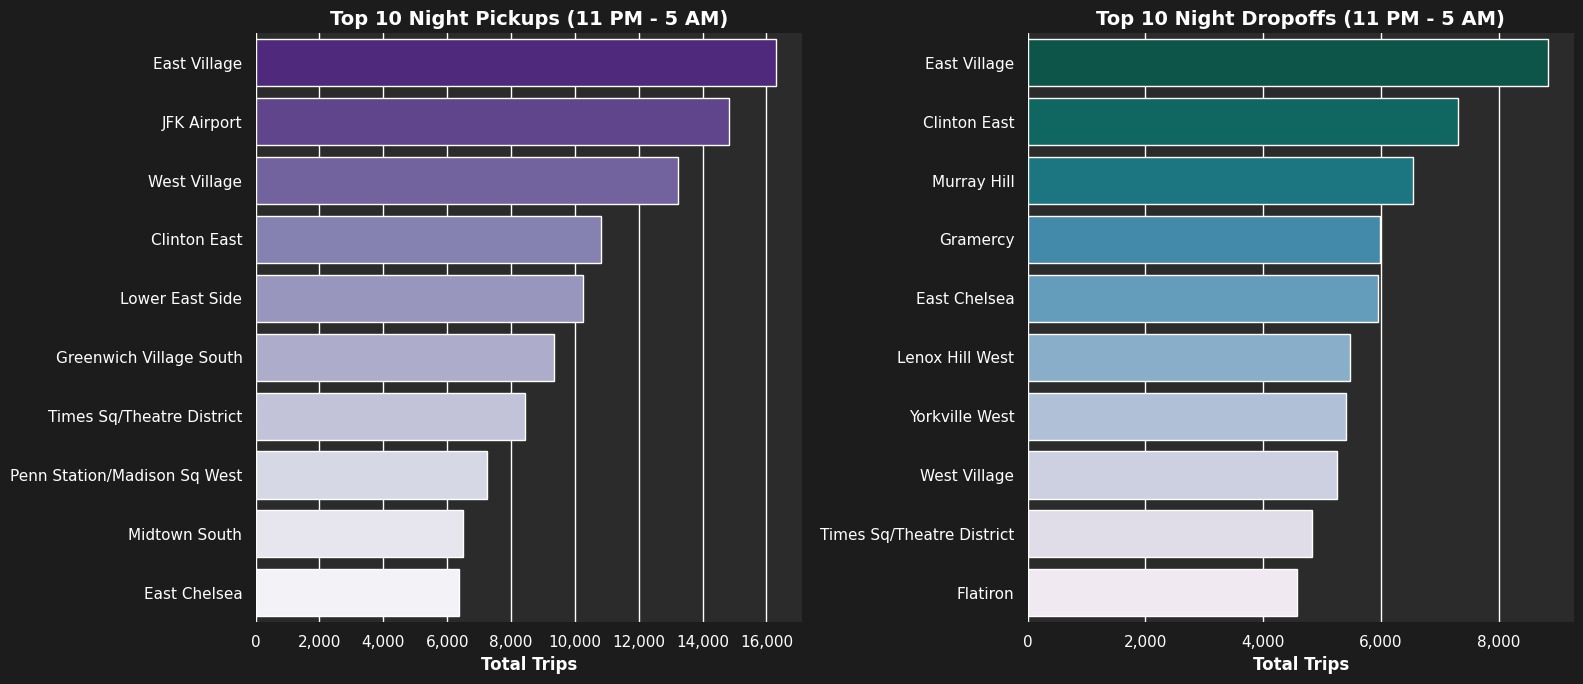

In [128]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones
night_df = df[df['hour'].isin([23, 0, 1, 2, 3, 4, 5])]
zone_dict = zones.set_index('LocationID')['zone'].to_dict()

top_pu = night_df['PULocationID'].value_counts().head(10).rename_axis('LocationID').reset_index(name='Trips')
top_pu['Zone'] = top_pu['LocationID'].map(zone_dict)

top_do = night_df['DOLocationID'].value_counts().head(10).rename_axis('LocationID').reset_index(name='Trips')
top_do['Zone'] = top_do['LocationID'].map(zone_dict)

display(top_pu.style.set_caption("Top 10 Night Pickup Zones").background_gradient(subset=['Trips'], cmap='Purples'))
display(top_do.style.set_caption("Top 10 Night Dropoff Zones").background_gradient(subset=['Trips'], cmap='PuBuGn'))

sns.set_theme(style="darkgrid", context="notebook")
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.barplot(data=top_pu, x='Trips', y='Zone', ax=axes[0], palette='Purples_r')
axes[0].set_title('Top 10 Night Pickups (11 PM - 5 AM)', fontsize=14, fontweight='bold', color='white')
axes[0].set_xlabel('Total Trips', fontsize=12, fontweight='bold', color='white')
axes[0].set_ylabel('')
axes[0].xaxis.set_major_formatter(FuncFormatter(lambda x, p: format(int(x), ',')))
axes[0].tick_params(colors='white')

sns.barplot(data=top_do, x='Trips', y='Zone', ax=axes[1], palette='PuBuGn_r')
axes[1].set_title('Top 10 Night Dropoffs (11 PM - 5 AM)', fontsize=14, fontweight='bold', color='white')
axes[1].set_xlabel('Total Trips', fontsize=12, fontweight='bold', color='white')
axes[1].set_ylabel('')
axes[1].xaxis.set_major_formatter(FuncFormatter(lambda x, p: format(int(x), ',')))
axes[1].tick_params(colors='white')

fig.patch.set_facecolor('#1c1c1c')
axes[0].set_facecolor('#2b2b2b')
axes[1].set_facecolor('#2b2b2b')

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()


Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

In [129]:
# Filter for night hours (11 PM to 5 AM)

df['time_of_day'] = np.where(df['hour'].isin([23, 0, 1, 2, 3, 4, 5]), 'Night', 'Day')
rev_df = df.groupby('time_of_day')['total_amount'].agg(
    Revenue='sum',
    Trip_Count='count'
).reset_index()
total_rev = rev_df['Revenue'].sum()
rev_df['Revenue_Share'] = rev_df['Revenue'] / total_rev
rev_df['Avg_Revenue_Per_Trip'] = rev_df['Revenue'] / rev_df['Trip_Count']
styled_table = (rev_df.style
    .set_caption("NYC Taxi Revenue: Day vs. Night (2023)")
    .format({
        "Revenue": "${:,.2f}",
        "Trip_Count": "{:,}",
        "Revenue_Share": "{:.2%}",
        "Avg_Revenue_Per_Trip": "${:.2f}"
    })
    .background_gradient(subset=['Revenue_Share'], cmap='YlGnBu')
    .hide(axis='index')
)

display(styled_table)

time_of_day,Revenue,Trip_Count,Revenue_Share,Avg_Revenue_Per_Trip
Day,"$48,168,267.59","1,667,175",87.66%,$28.89
Night,"$6,779,441.14","229,047",12.34%,$29.60


##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

In [130]:
# Analyse the fare per mile per passenger for different passenger counts
pax_df = df[(df['trip_distance'] > 0) & (df['passenger_count'] > 0)][['passenger_count', 'trip_distance','total_amount']]
pax_df = pax_df.groupby(['passenger_count']).sum()
pax_df['avg_fare_per_mile'] = pax_df['trip_distance'] / pax_df['total_amount']
pax_df.reset_index(inplace=True)
pax_df['avg_fare_per_mile_per_pax'] = pax_df['avg_fare_per_mile'] / pax_df['passenger_count']
pax_df



,passenger_count,trip_distance,total_amount,avg_fare_per_mile,avg_fare_per_mile_per_pax
0,1.0,4784555.94,39827201.38,0.120133,0.120133
1,2.0,1128891.90,8734013.71,0.129252,0.064626
2,3.0,268638.98,2129315.48,0.126162,0.042054
3,4.0,162177.71,1254564.27,0.129270,0.032318
4,5.0,81869.90,676618.47,0.120999,0.024200
5,6.0,52880.22,438999.08,0.120456,0.020076


**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

In [131]:
# Compare the average fare per mile for different days and for different times of the day
temp_df = df[(df['trip_distance'] > 0) & (df['total_amount'] > 0)][['trip_distance','total_amount','hour','pickup_day']]
temp_df['fare_per_mile'] = temp_df['trip_distance'] / temp_df['total_amount']
hourly_avg_df = temp_df.groupby(['hour'])['fare_per_mile'].mean().reset_index()
hourly_avg_df.reset_index()
hourly_avg_df


,hour,fare_per_mile
0,0,0.113362
1,1,0.112208
2,2,0.112121
3,3,0.118334
4,4,0.132004
5,5,0.134458
6,6,0.125845
7,7,0.110313
8,8,0.100393
9,9,0.098323


In [ ]:
Day_avg_df = temp_df.groupby(['pickup_day'])['fare_per_mile'].mean().reset_index()
Day_avg_df

**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

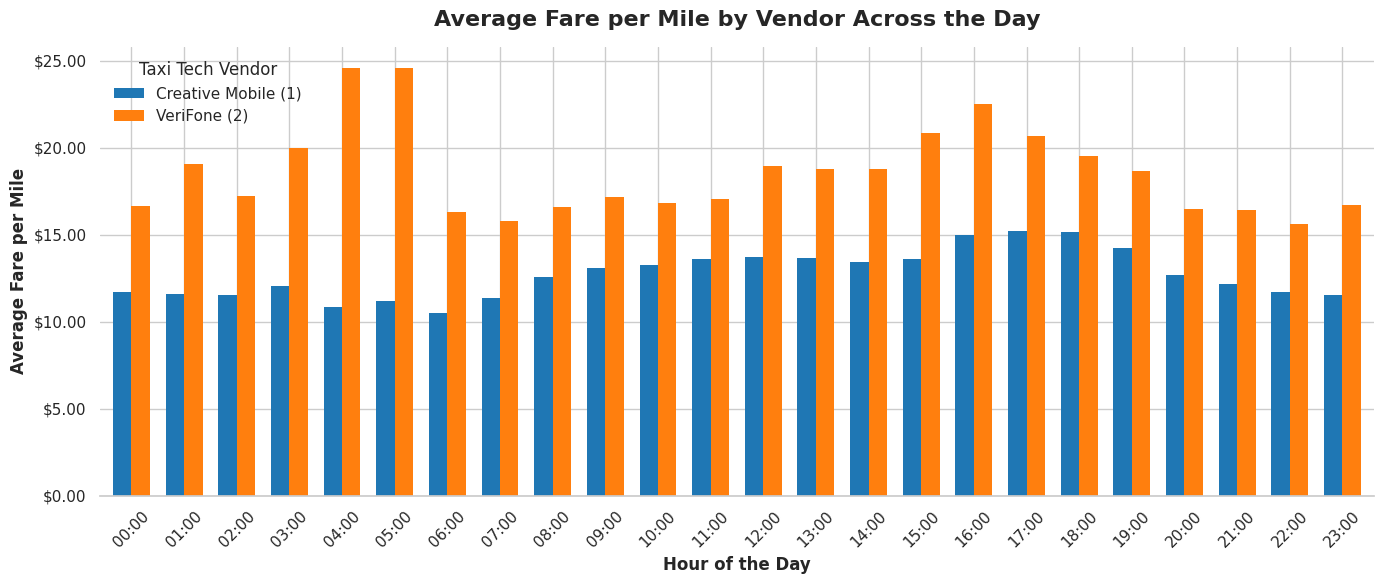

In [132]:
# Compare fare per mile for different vendors
valid_trips = df[
    (df['trip_distance'] > 0) &
    (df['total_amount'] > 0) &
    (df['VendorID'].isin([1, 2]))
].copy()

valid_trips['fare_per_mile'] = valid_trips['total_amount'] / valid_trips['trip_distance']

vendor_df = valid_trips.groupby(['hour', 'VendorID'])['fare_per_mile'].mean().reset_index()
vendor_df['Vendor'] = vendor_df['VendorID'].map({1: 'Creative Mobile (1)', 2: 'VeriFone (2)'})
vendor_pivot = vendor_df.pivot(index='hour', columns='Vendor', values='fare_per_mile')

sns.set_theme(style="whitegrid", context="notebook")

colors = ['#1f77b4', '#ff7f0e']
ax = vendor_pivot.plot(kind='bar', figsize=(14, 6), width=0.7, color=colors, edgecolor='none')

plt.title('Average Fare per Mile by Vendor Across the Day', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Hour of the Day', fontsize=12, fontweight='bold')
plt.ylabel('Average Fare per Mile', fontsize=12, fontweight='bold')

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${x:,.2f}'))
ax.set_xticklabels([f"{h:02d}:00" for h in vendor_pivot.index], rotation=45)

sns.despine(left=True)
plt.legend(title='Taxi Tech Vendor', frameon=False, loc='upper left')
plt.tight_layout()
plt.show()


**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


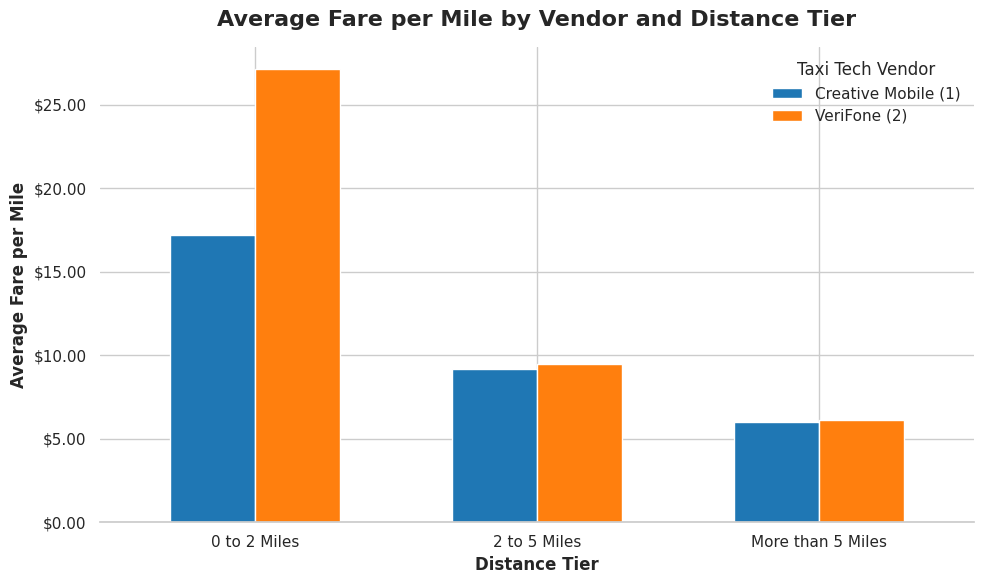

In [133]:
# Defining distance tiers

valid_df = df[
    (df['trip_distance'] > 0) &
    (df['total_amount'] > 0) &
    (df['VendorID'].isin([1, 2]))
].copy()

valid_df['fare_per_mile'] = valid_df['total_amount'] / valid_df['trip_distance']

bins = [0, 2, 5, float('inf')]
labels = ['0 to 2 Miles', '2 to 5 Miles', 'More than 5 Miles']
valid_df['tier'] = pd.cut(valid_df['trip_distance'], bins=bins, labels=labels)

tier_df = valid_df.groupby(['tier', 'VendorID'])['fare_per_mile'].mean().reset_index()

tier_df['Vendor'] = tier_df['VendorID'].map({1: 'Creative Mobile (1)', 2: 'VeriFone (2)'})
tier_pivot = tier_df.pivot(index='tier', columns='Vendor', values='fare_per_mile')

sns.set_theme(style="whitegrid", context="notebook")
ax = tier_pivot.plot(kind='bar', figsize=(10, 6), width=0.6, color=['#1f77b4', '#ff7f0e'])

plt.title('Average Fare per Mile by Vendor and Distance Tier', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Distance Tier', fontsize=12, fontweight='bold')
plt.ylabel('Average Fare per Mile', fontsize=12, fontweight='bold')

# Keep x-axis text flat and format y-axis as currency
plt.xticks(rotation=0)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${x:,.2f}'))

sns.despine(left=True)
plt.legend(title='Taxi Tech Vendor', frameon=False)
plt.tight_layout()
plt.show()

##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

In [134]:
#  Analyze tip percentages based on distances, passenger counts and pickup times

valid_df = df[
    (df['trip_distance'] > 0) &
    (df['total_amount'] > df['tip_amount']) &
    (df['passenger_count'] > 0) &
    (df['payment_type'] == 1)
].copy()


valid_df['tip_percentage'] = (valid_df['tip_amount'] / (valid_df['total_amount'] - valid_df['tip_amount'])) * 100

valid_df = valid_df[(valid_df['tip_percentage'] >= 0) & (valid_df['tip_percentage'] <= 100)]

dist_bins = [0, 2, 5, float('inf')]
dist_labels = ['0 to 2 Miles', '2 to 5 Miles', 'More than 5 Miles']
valid_df['Distance_tier'] = pd.cut(valid_df['trip_distance'], bins=dist_bins, labels=dist_labels)

time_bins = [-1, 6, 12, 18, 24]
time_labels = ['Early Morning (0-6)', 'Morning (7-12)', 'Afternoon (13-18)', 'Evening (19-23)']
valid_df['Time_period'] = pd.cut(valid_df['hour'], bins=time_bins, labels=time_labels)

tip_analysis = valid_df.groupby(['Distance_tier', 'Time_period', 'passenger_count'])['tip_percentage'].mean().reset_index()

lowest_tips = tip_analysis.sort_values(by='tip_percentage', ascending=True).head(10)

print("Top 10 Scenarios with the LOWEST Tip Percentages:")
display(lowest_tips.style.format({'tip_percentage': '{:.2f}%'}))

Top 10 Scenarios with the LOWEST Tip Percentages:


,Distance_tier,Time_period,passenger_count,tip_percentage
53,More than 5 Miles,Early Morning (0-6),6.000000,15.58%
48,More than 5 Miles,Early Morning (0-6),1.000000,15.82%
50,More than 5 Miles,Early Morning (0-6),3.000000,15.89%
26,2 to 5 Miles,Early Morning (0-6),3.000000,15.97%
51,More than 5 Miles,Early Morning (0-6),4.000000,16.05%
69,More than 5 Miles,Evening (19-23),4.000000,16.28%
54,More than 5 Miles,Morning (7-12),1.000000,16.32%
49,More than 5 Miles,Early Morning (0-6),2.000000,16.35%
52,More than 5 Miles,Early Morning (0-6),5.000000,16.44%
25,2 to 5 Miles,Early Morning (0-6),2.000000,16.45%


Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [135]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%
valid_df = df[
    (df['trip_distance'] > 0) &
    (df['total_amount'] > df['tip_amount']) &
    (df['passenger_count'] > 0) &
    (df['payment_type'] == 1)
].copy()

valid_df['tip_percentage'] = (valid_df['tip_amount'] / (valid_df['total_amount'] - valid_df['tip_amount'])) * 100

low_tips = valid_df[valid_df['tip_percentage'] < 10].copy()
low_tips['tip_bucket'] = 'Low Tip (< 10%)'

high_tips = valid_df[valid_df['tip_percentage'] > 25].copy()
high_tips['tip_bucket'] = 'High Tip (> 25%)'

extreme_tips = pd.concat([low_tips, high_tips])

comparison = extreme_tips.groupby('tip_bucket').agg(
    Avg_Distance_Miles=('trip_distance', 'mean'),
    Avg_Fare_Amount=('total_amount', 'mean'),
    Avg_Passenger_Count=('passenger_count', 'mean'),
    Avg_Hour_of_Day=('hour', 'mean'),
    Total_Trips_in_Bucket=('trip_distance', 'count')
).reset_index()

styled_comparison = (comparison.style
    .set_caption("Tipping Behavior: High vs Low Tips")
    .format({
        "Avg_Distance_Miles": "{:.2f} mi",
        "Avg_Fare_Amount": "${:.2f}",
        "Avg_Passenger_Count": "{:.2f}",
        "Avg_Hour_of_Day": "{:.1f}",
        "Total_Trips_in_Bucket": "{:,}"
    })
    .background_gradient(subset=['Avg_Distance_Miles', 'Avg_Fare_Amount'], cmap='Blues')
)

display(styled_comparison)


,tip_bucket,Avg_Distance_Miles,Avg_Fare_Amount,Avg_Passenger_Count,Avg_Hour_of_Day,Total_Trips_in_Bucket
0,High Tip (> 25%),3.00 mi,$29.93,1.36,14.1,"94,661"
1,Low Tip (< 10%),4.18 mi,$29.54,1.37,14.0,"211,831"


**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

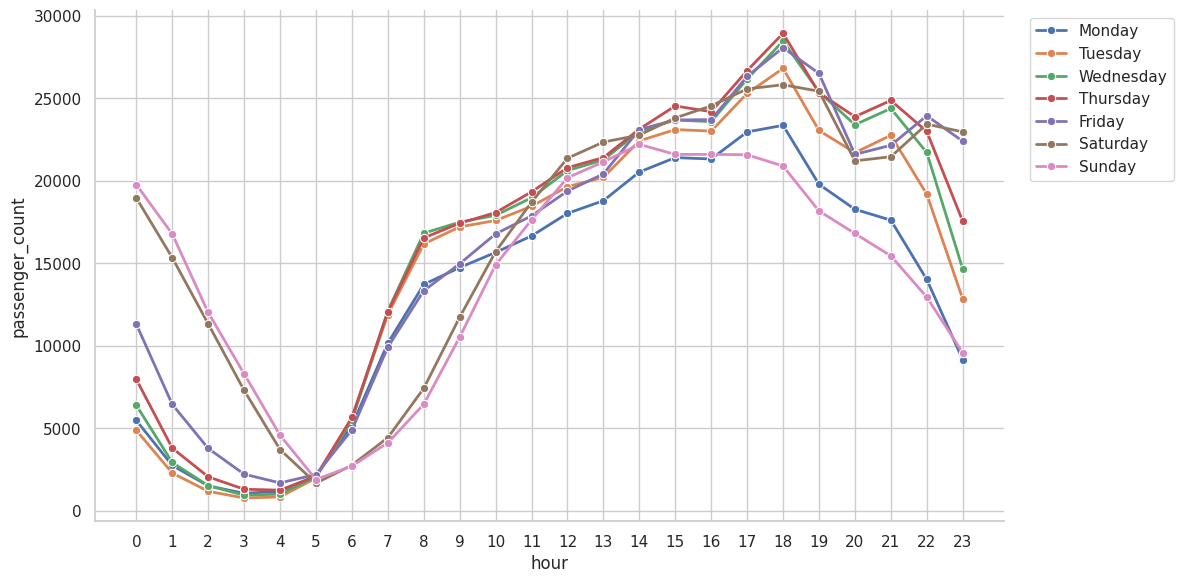

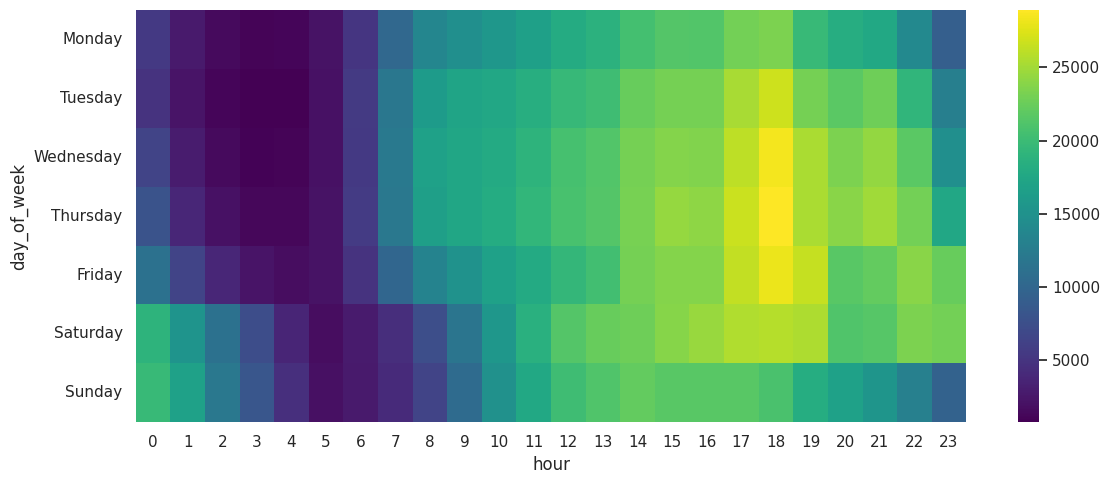

In [137]:
# See how passenger count varies across hours and days

df['hour'] = df['tpep_pickup_datetime'].dt.hour
df['day_of_week'] = df['tpep_pickup_datetime'].dt.day_name()

pax_agg = df[df['passenger_count'] > 0].groupby(['day_of_week', 'hour'], as_index=False)['passenger_count'].sum()
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(12, 6))
sns.lineplot(data=pax_agg, x='hour', y='passenger_count', hue='day_of_week', hue_order=order, marker='o', linewidth=2)
plt.xticks(range(24))
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
sns.despine()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
pax_pivot = pax_agg.pivot(index='day_of_week', columns='hour', values='passenger_count').reindex(order)
sns.heatmap(pax_pivot, cmap='viridis', annot=False)
plt.tight_layout()
plt.show()


**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

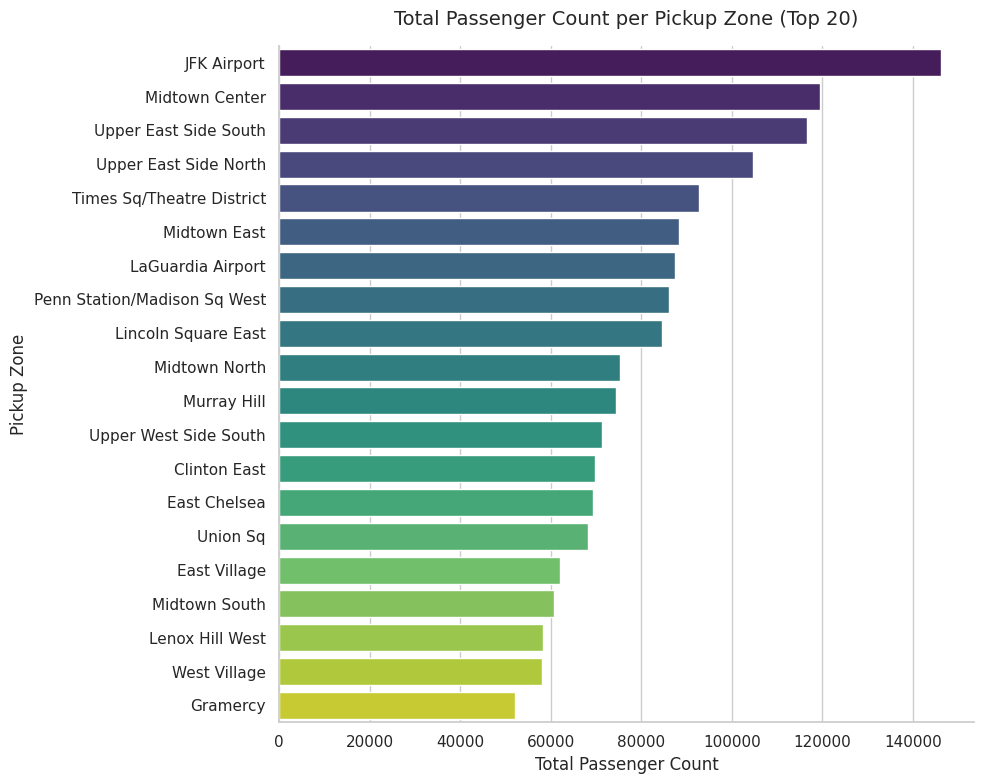

In [138]:
# How does passenger count vary across zones

zone_pax = df.groupby('PULocationID')['passenger_count'].sum().reset_index()
zone_pax = zone_pax.merge(zones[['LocationID', 'zone']], left_on='PULocationID', right_on='LocationID')
top_zones = zone_pax.groupby('zone')['passenger_count'].sum().nlargest(20).reset_index()

plt.figure(figsize=(10, 8))
sns.barplot(data=top_zones, x='passenger_count', y='zone', palette='viridis')
plt.title('Total Passenger Count per Pickup Zone (Top 20)', fontsize=14, pad=15)
plt.xlabel('Total Passenger Count', fontsize=12)
plt.ylabel('Pickup Zone', fontsize=12)
sns.despine()
plt.tight_layout()
plt.show()

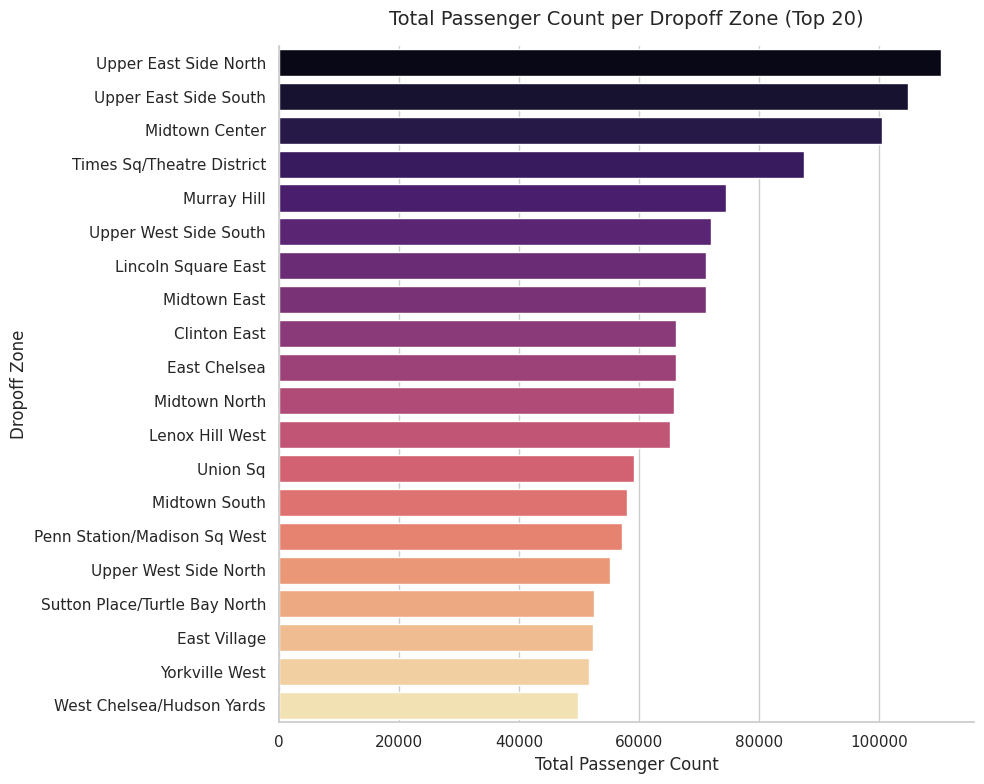

In [139]:
zone_pax = df.groupby('DOLocationID')['passenger_count'].sum().reset_index()
zone_pax = zone_pax.merge(zones[['LocationID', 'zone']], left_on='DOLocationID', right_on='LocationID')
top_zones = zone_pax.groupby('zone')['passenger_count'].sum().nlargest(20).reset_index()

plt.figure(figsize=(10, 8))
sns.barplot(data=top_zones, x='passenger_count', y='zone', palette='magma')
plt.title('Total Passenger Count per Dropoff Zone (Top 20)', fontsize=14, pad=15)
plt.xlabel('Total Passenger Count', fontsize=12)
plt.ylabel('Dropoff Zone', fontsize=12)
sns.despine()
plt.tight_layout()
plt.show()

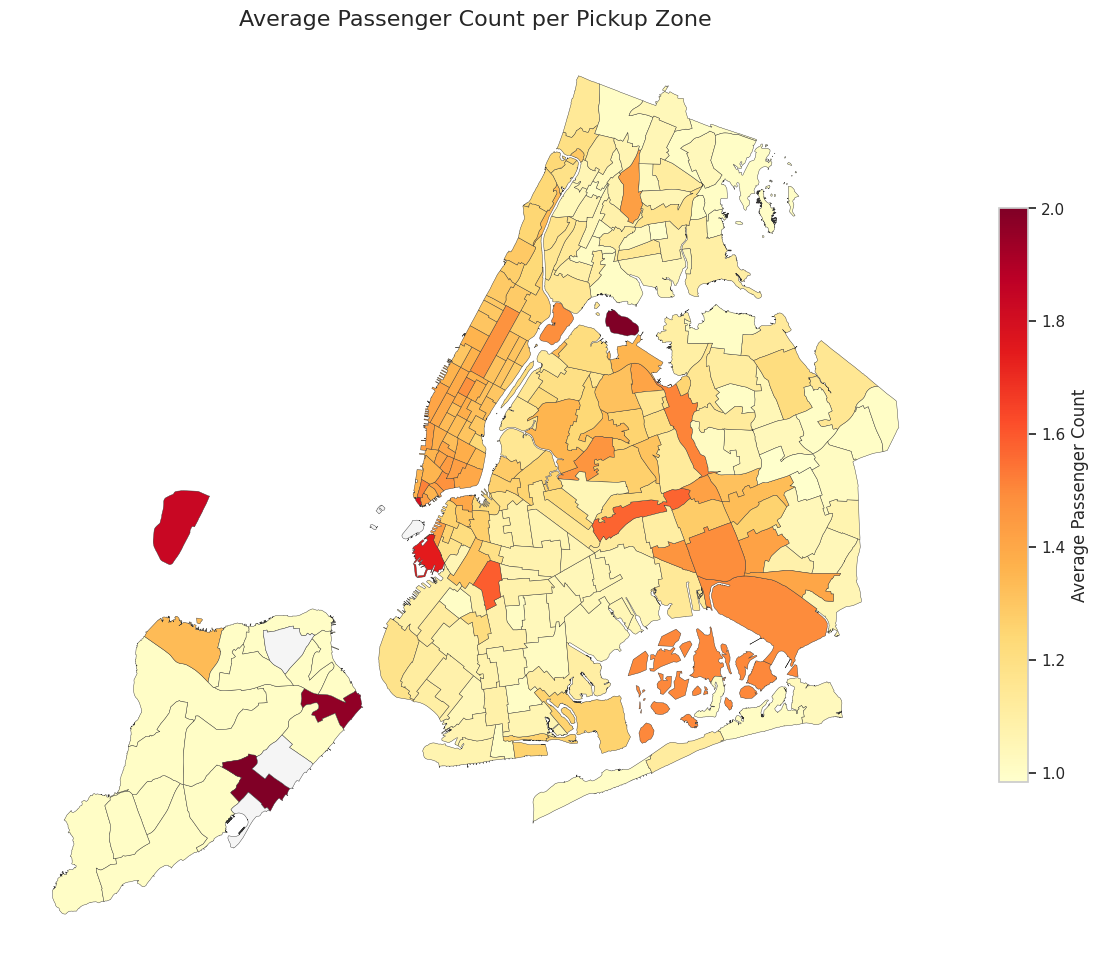

In [140]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.
avg_pax = df.groupby('PULocationID')['passenger_count'].mean().rename('avg_passenger_count')
trip_zones_df = trip_zones_df.merge(avg_pax, left_on='LocationID', right_index=True, how='left')

import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
trip_zones_df.plot(column='avg_passenger_count', cmap='YlOrRd', linewidth=0.3, edgecolor='0.2',
                   legend=True, legend_kwds={'label': 'Average Passenger Count', 'shrink': 0.6},
                   missing_kwds={'color': 'whitesmoke', 'label': 'No Data'}, ax=ax)
ax.set_axis_off()
plt.title('Average Passenger Count per Pickup Zone', fontsize=16)
plt.tight_layout()
plt.show()


Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

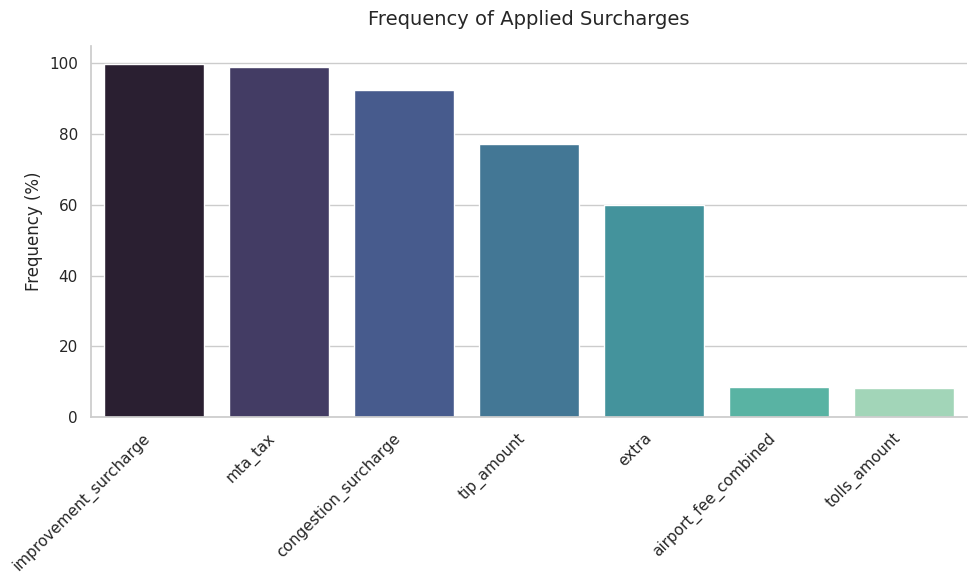

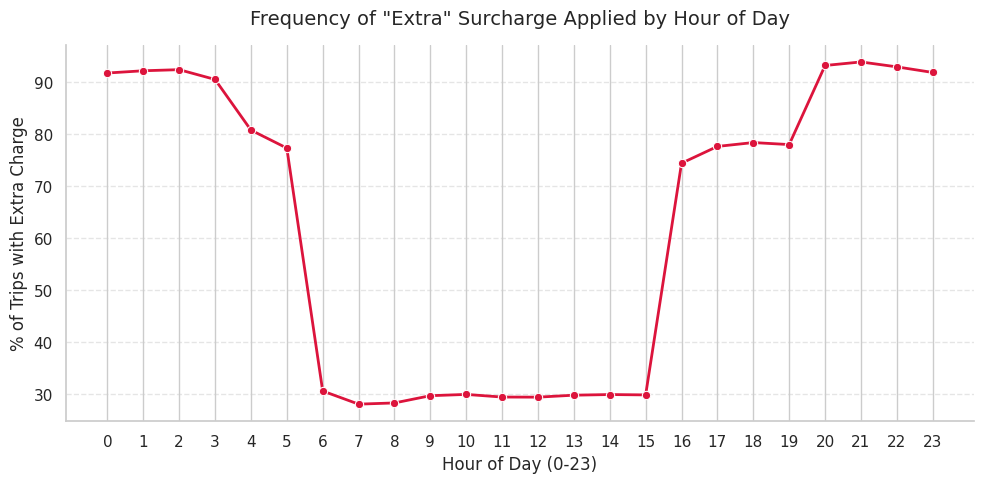

In [141]:
# How often is each surcharge applied?

surcharge_columns = ['extra', 'mta_tax', 'tip_amount', 'tolls_amount',
                     'improvement_surcharge', 'congestion_surcharge', 'airport_fee_combined']

surcharge_freq = (df[surcharge_columns] > 0).mean() * 100
surcharge_freq = surcharge_freq.sort_values(ascending=False).reset_index()
surcharge_freq.columns = ['Surcharge Type', 'Frequency (%)']

plt.figure(figsize=(10, 6))
sns.barplot(data=surcharge_freq, x='Surcharge Type', y='Frequency (%)', palette='mako')
plt.title('Frequency of Applied Surcharges', fontsize=14, pad=15)
plt.ylabel('Frequency (%)', fontsize=12)
plt.xlabel('')
plt.xticks(rotation=45, ha='right')
sns.despine()
plt.tight_layout()
plt.show()

df['hour'] = df['tpep_pickup_datetime'].dt.hour
extra_by_hour = (df[df['extra'] > 0].groupby('hour').size() / df.groupby('hour').size()) * 100

plt.figure(figsize=(10, 5))
sns.lineplot(x=extra_by_hour.index, y=extra_by_hour.values, marker='o', linewidth=2, color='crimson')
plt.title('Frequency of "Extra" Surcharge Applied by Hour of Day', fontsize=14, pad=15)
plt.xlabel('Hour of Day (0-23)', fontsize=12)
plt.ylabel('% of Trips with Extra Charge', fontsize=12)
plt.xticks(range(24))
plt.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine()
plt.tight_layout()
plt.show()


## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

**Analytical Discoveries**:


*   **Temporal Demand Patterns**: The data reveals a clear and predictable rhythm in how passengers use taxis. On weekdays, demand reliably peaks during standard commute windows: 6:00 AM to 9:00 AM and again from 5:00 PM to 7:00 PM. Weekends follow an entirely different pattern, with the busiest period falling between midnight and 3:00 AM, fueled by nightlife activity. Regardless of the day, the one hour window between 4:00 AM and 5:00 AM consistently records the fewest ride requests.
*   **Revenue and Surcharge Drivers**: While base fares are mainly driven by trip distance and time, certain hours offer significantly higher earning potential. TLC "Extra" fees are successfully applied to over 90% of trips during the evening rush (4:00 PM to 8:00 PM) and overnight hours (8:00 PM to 6:00 AM). Tips, though not mandatory, are also widespread, appearing in roughly 75% of all recorded trips.
*   **Geographic Distribution and Party Size**: The majority of taxi trips are concentrated in core Manhattan areas, particularly Midtown, Penn Station, Times Square, and the Upper East Side. However, when looking at passenger counts per trip rather than total trip volume, a different picture emerges: pickups from outer boroughs and major airports like JFK and LaGuardia tend to carry noticeably larger groups compared to the mostly solo riders that dominate Manhattan routes.

**Actionable Dispatch Strategies**:

*   **Anticipatory Fleet Positioning:** Fleet managers should move away from reacting to demand and instead focus on predicting it. Vehicles should be staged in key Manhattan commercial zones just before the 5:00 PM weekday peak. On Fridays and Saturdays, available cars should be redirected toward nightlife and entertainment areas before midnight to take full advantage of the weekend late night surge.
*   **Minimizing Revenue Leakage:** Since 4:00 AM to 5:00 AM is the slowest hour of the day across all days of the week, operators should use this window exclusively for activities that do not generate revenue, such as driver shift changes, refueling, and routine vehicle maintenance. This ensures that no earning opportunities are missed.
* **Maximizing Premium Fares:** Driver incentives should be structured to keep as many vehicles active as possible between 4:00 PM and 8:00 PM and from 8:00 PM to 6:00 AM. Trips during these hours almost always qualify for TLC surcharges, meaning more drivers on the road during these windows directly translates to higher average earnings per trip.
*   **Optimizing Vehicle Utility:** Larger vehicles such as SUVs and passenger vans should be prioritized for airport queues at JFK and LaGuardia and for outer borough pickups, where larger travel groups are far more common. Standard sedans are better deployed within Manhattan, where the demand is high in volume but mostly consists of individual passengers.

**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

My suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months:
#### Scheduling and Fleet Availability:
Operators need to align vehicle availability with when passengers actually need rides. The data clearly points to three peak windows that require maximum fleet presence: weekday mornings from 6:00 AM to 9:00 AM, weekday evenings from 5:00 PM to 7:00 PM, and the weekend late night rush from midnight to 3:00 AM. To avoid cutting into these earning hours, all maintenance, refueling, and driver shift changes should be scheduled strictly between 4:00 AM and 5:00 AM, when demand is at its lowest.

#### Optimizing Premium Fare Windows:
Trip data shows that TLC "Extra" surcharges are applied to more than 90% of rides between 4:00 PM and 8:00 PM, as well as throughout the overnight block from 8:00 PM to 6:00 AM. Management should build driver incentive programs that reward working during these specific hours, as doing so directly increases the average revenue earned per trip.

#### Proactive Hotspot Staging:
Dispatch systems should be designed to anticipate demand rather than simply respond to it. Positioning unassigned vehicles near high traffic areas like Times Square, Penn Station, Midtown, and the Upper East Side just before the 5:00 PM weekday rush allows operators to stay ahead of demand and maintain a steady flow of back to back fares.

#### Capacity Driven Dispatching:
Data consistently shows that trips starting at JFK, LaGuardia, and outer borough locations tend to carry larger groups of passengers. Dispatchers should assign larger vehicles like SUVs to these zones to comfortably handle group travel, while keeping standard sedans focused on Manhattan, where most trips involve just one passenger.


**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.

## Data-Driven Pricing Adjustments

### Time-Based and Surcharge Optimization

The data shows that TLC "Extra" surcharges are successfully applied to over 90% of rides during the evening rush (4:00 PM to 8:00 PM) and overnight hours (8:00 PM to 6:00 AM). Since passengers are already used to paying more during these periods, operators could introduce a "Guaranteed Ride" flat rate option during the absolute peak windows — weekday evenings from 5:00 PM to 7:00 PM and weekends from midnight to 3:00 AM. This approach maximizes revenue while offering passengers clear, upfront pricing as a transparent alternative to rideshare apps.

### Off-Peak Demand Stimulation

The data clearly identifies 4:00 AM to 5:00 AM as the quietest period of the day for ride demand. To encourage more trips during this slow window and the surrounding early morning hours, operators should offer discounted flat fares or promotional rates specifically targeting early shift workers and passengers with early morning airport departures.

### Zone and Capacity Based Pricing

While Manhattan areas like Midtown, Times Square, and Penn Station account for the highest number of total trips, most of these rides carry just one passenger. In contrast, trips originating from JFK, LaGuardia, and the outer boroughs consistently carry larger groups. To take advantage of this, operators should introduce a "High Capacity Flat Rate" for larger vehicles like SUVs serving airports and outer borough zones, while keeping fares competitive and affordable for short, single passenger trips within the Manhattan core.

### Tip and Experience Incentivization

Tips are currently added to roughly 75% of all trips. By introducing a simple, prompt based tipping interface with slightly higher default tip percentages for late night rides (midnight to 3:00 AM) and group trips from airports, operators can meaningfully increase total driver earnings without raising the base fare for passengers.
